In [ ]:
# !uv add pandas numpy scikit-learn matplotlib seaborn \
#        xgboost lightgbm catboost \
#        torch torchvision \
#        optuna shap imbalanced-learn

Resolved 180 packages in 343ms                                       
⠙ Preparing packages... (0/7)                                                   ⠋ Preparing packages... (0/0)                                                   
⠙ Preparing packages... (0/7)--------------     0 B/307.42 MiB          
⠙ Preparing packages... (0/7)-------------- 16.00 KiB/307.42 MiB        
⠙ Preparing packages... (0/7)-------------- 16.00 KiB/307.42 MiB        
cuda-pathfinder      ------------------------------     0 B/26.52 KiB
⠙ Preparing packages... (0/7)-------------- 16.00 KiB/307.42 MiB        
cuda-pathfinder      ------------------------------     0 B/26.52 KiB
⠙ Preparing packages... (0/7)-------------- 16.00 KiB/307.42 MiB        
cuda-pathfinder      ------------------------------     0 B/26.52 KiB
⠙ Preparing packages... (0/7)-------------- 16.00 KiB/307.42 MiB        
cuda-pathfinder      ------------------------------     0 B/26.52 KiB
nvidia-nvshmem-cu12  ------------------------------

In [ ]:
# !uv add pandas numpy scikit-learn matplotlib seaborn \
#        xgboost lightgbm catboost \
#        tensorflow keras \
#        optuna shap imbalanced-learn

Resolved 201 packages in 245ms                                       
⠙ Preparing packages... (0/20)                                                  ⠋ Preparing packages... (0/0)                                                   
⠙ Preparing packages... (0/20)-------------     0 B/12.43 KiB           
⠙ Preparing packages... (0/20)--------- 12.43 KiB/12.43 KiB         
⠙ Preparing packages... (0/20)--------- 12.43 KiB/12.43 KiB         
termcolor            ------------------------------     0 B/7.55 KiB
⠙ Preparing packages... (0/20)--------- 12.43 KiB/12.43 KiB         
termcolor            ------------------------------ 7.55 KiB/7.55 KiB
⠙ Preparing packages... (0/20)--------- 12.43 KiB/12.43 KiB         
termcolor            ------------------------------ 7.55 KiB/7.55 KiB
⠙ Preparing packages... (0/20)--------- 12.43 KiB/12.43 KiB         
termcolor            ------------------------------ 7.55 KiB/7.55 KiB
⠙ Preparing packages... (0/20)--------- 12.43 KiB/12.43 KiB         
nam

In [ ]:
# !uv add pandas numpy scikit-learn matplotlib seaborn \
#        xgboost lightgbm catboost \
#        optuna shap imbalanced-learn

Resolved 201 packages in 1ms
Audited 198 packages in 3ms


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 데이터 로드
df = pd.read_csv('preprocessed_shelter_data.csv')

# 보호중 제외 (target >= 0)
df_model = df[df['target'] >= 0].copy()

print(f"총 데이터: {len(df_model)}건")
print(f"\n타겟 분포:")
print(df_model['target'].value_counts().sort_index())
print(f"\n클래스 비율:")
print(df_model['target'].value_counts(normalize=True).sort_index())

총 데이터: 2650건

타겟 분포:
target
0    1612
1     332
2     706
Name: count, dtype: int64

클래스 비율:
target
0    0.608302
1    0.125283
2    0.266415
Name: proportion, dtype: float64


In [4]:
# 제외할 컬럼 (메타데이터, 원본 텍스트)
exclude_cols = ['desertionNo', 'happenDt', 'processState', 'specialMark']

# 타겟 분리
X = df_model.drop(['target'] + exclude_cols, axis=1)
y = df_model['target']

print(f"피처 수: {X.shape[1]}개")
print(f"샘플 수: {X.shape[0]}건")

피처 수: 20개
샘플 수: 2650건


In [5]:
from sklearn.preprocessing import LabelEncoder

# 카테고리 변수 리스트
categorical_features = [
    'shelter_size_category',  # 소형/중형/대형/초대형
    'age_group',              # 자견/성견/노령견
    'sex_neutered',           # M_Y, M_N, F_Y, F_N, etc
    'province',               # 경기도/부산광역시
    'city',                   # 시/군/구
    'careNm'                  # 보호소 이름
]

# 방법 1: Label Encoding (트리 기반 모델용)
X_encoded = X.copy()
label_encoders = {}

for col in categorical_features:
    if col in X_encoded.columns:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
        label_encoders[col] = le

# 방법 2: One-Hot Encoding (선형 모델용)
X_onehot = pd.get_dummies(
    X, 
    columns=categorical_features,
    drop_first=True  # 다중공선성 방지
)

print(f"\nLabel Encoding 후: {X_encoded.shape[1]}개 피처")
print(f"One-Hot Encoding 후: {X_onehot.shape[1]}개 피처")


Label Encoding 후: 20개 피처
One-Hot Encoding 후: 106개 피처


In [6]:
from sklearn.preprocessing import StandardScaler

# 스케일링이 필요한 수치형 피처
numeric_features = [
    'shelter_total_count',
    'shelter_recent_30d_load',
    'stay_duration_days',
    'health_sentiment_score',
    'notice_period_days',
    'weight_kg',
    'crowding_health_risk',
    'golden_attack_risk',
    'total_risk_score'
]

# 트리 기반 모델은 스케일링 불필요하지만, 
# 선형 모델/신경망에는 필수!

scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[numeric_features] = scaler.fit_transform(X_encoded[numeric_features])

In [7]:
from sklearn.model_selection import train_test_split

# Train : Valid : Test = 70 : 15 : 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded,  # 또는 X_onehot, X_scaled
    y, 
    test_size=0.3, 
    stratify=y,  # 클래스 비율 유지
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.5, 
    stratify=y_temp,
    random_state=42
)

print(f"Train: {len(X_train)}건")
print(f"Valid: {len(X_val)}건")
print(f"Test:  {len(X_test)}건")

print(f"\nTrain 클래스 분포:")
print(y_train.value_counts(normalize=True).sort_index())

Train: 1855건
Valid: 397건
Test:  398건

Train 클래스 분포:
target
0    0.608086
1    0.125606
2    0.266307
Name: proportion, dtype: float64


In [8]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

# XGBoost 버전 확인 (선택)
print(f"XGBoost version: {xgb.__version__}")

# 모델 초기화 (XGBoost 2.0+ 방식)
model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    early_stopping_rounds=20,  # ✅ 초기화 시점으로 이동
    verbose=1  # 학습 과정 출력
)

# 학습
print("\n=== 모델 학습 시작 ===")
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=10  # 10번 반복마다 출력
)

# Best iteration 확인
print(f"\nBest iteration: {model.best_iteration}")
print(f"Best score: {model.best_score:.4f}")

# 예측
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# 평가
print("\n=== Test Set 성능 ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred, 
    target_names=['생존', '자연사', '안락사']
))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# 혼동 행렬을 DataFrame으로 보기 좋게 출력
cm_df = pd.DataFrame(
    cm,
    index=['실제: 생존', '실제: 자연사', '실제: 안락사'],
    columns=['예측: 생존', '예측: 자연사', '예측: 안락사']
)
print("\n혼동 행렬 (DataFrame):")
print(cm_df)

XGBoost version: 3.1.3

=== 모델 학습 시작 ===
[0]	validation_0-mlogloss:0.94555
[10]	validation_0-mlogloss:0.69679
[20]	validation_0-mlogloss:0.61234
[30]	validation_0-mlogloss:0.58690
[40]	validation_0-mlogloss:0.57540
[50]	validation_0-mlogloss:0.56799
[60]	validation_0-mlogloss:0.56898
[70]	validation_0-mlogloss:0.56954
[72]	validation_0-mlogloss:0.57098

Best iteration: 52
Best score: 0.5675



=== Test Set 성능 ===
Accuracy: 0.7513

Classification Report:
              precision    recall  f1-score   support

          생존       0.84      0.78      0.81       242
         자연사       0.69      0.48      0.56        50
         안락사       0.63      0.81      0.71       106

    accuracy                           0.75       398
   macro avg       0.72      0.69      0.69       398
weighted avg       0.76      0.75      0.75       398


Confusion Matrix:
[[189   8  45]
 [ 20  24   6]
 [ 17   3  86]]

혼동 행렬 (DataFrame):
         예측: 생존  예측: 자연사  예측: 안락사
실제: 생존      189        8       45
실제: 자연사      20       24        6
실제: 안락사      17        3       86


/teamspace/studios/this_studio/.venv/lib/python3.13/site-packages/xgboost/callback.py:386: UserWarning: [07:47:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "verbose" } are not used.

  self.starting_round = model.num_boosted_rounds()



상위 10개 중요 피처:
                   feature  importance
10                is_mixed    0.240360
0      shelter_total_count    0.125717
5         has_health_issue    0.095945
14                province    0.060522
16                  careNm    0.052315
15                    city    0.044480
12               weight_kg    0.041277
3    shelter_size_category    0.040066
17    crowding_health_risk    0.036755
4   health_sentiment_score    0.034187


<Figure size 1000x800 with 0 Axes>

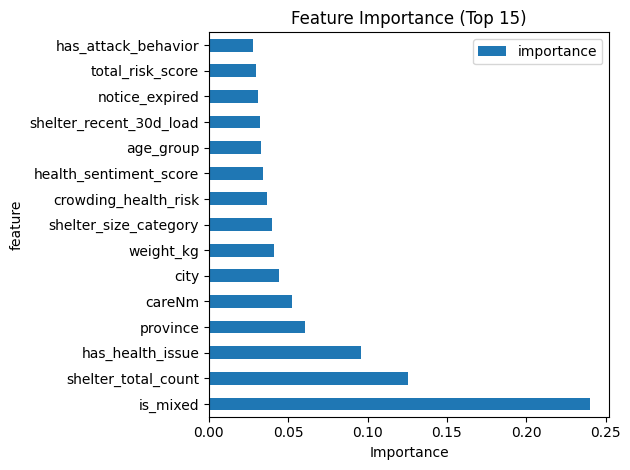

In [9]:
### 피처 중요도 분석

import matplotlib.pyplot as plt

# 피처 중요도
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n상위 10개 중요 피처:")
print(feature_importance.head(10))

# 시각화
plt.figure(figsize=(10, 8))
feature_importance.head(15).plot(
    x='feature', y='importance', 
    kind='barh', 
    title='Feature Importance (Top 15)'
)
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)

In [1]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt

print("=" * 80)
print("이미지 데이터 탐색")
print("=" * 80)

# 원본 데이터 로드
df = pd.read_csv('preprocessed_shelter_data.csv')

print(f"\n전체 데이터: {len(df)}건")

# 이미지 URL 컬럼 확인
image_cols = ['popfile', 'popfile1', 'popfile2', 'popfile3']
existing_cols = [col for col in image_cols if col in df.columns]

print(f"\n이미지 컬럼: {existing_cols}")

# 이미지 있는 데이터 확인
for col in existing_cols:
    non_null = df[col].notna().sum()
    print(f"  {col}: {non_null}건 ({non_null/len(df)*100:.1f}%)")

# 샘플 확인
print("\n샘플 5개 이미지 URL:")
for i, row in df.head(5).iterrows():
    print(f"\n{i+1}. desertionNo: {row['desertionNo']}")
    for col in existing_cols:
        if pd.notna(row[col]):
            print(f"   {col}: {row[col][:80]}...")

# 이미지 개수 분포
print("\n이미지 개수 분포:")
df['image_count'] = df[existing_cols].notna().sum(axis=1)
print(df['image_count'].value_counts().sort_index())

print("\n평균 이미지 개수:", df['image_count'].mean())

이미지 데이터 탐색

전체 데이터: 3302건

이미지 컬럼: []

샘플 5개 이미지 URL:

1. desertionNo: 426329202500809

2. desertionNo: 441553202503176

3. desertionNo: 441553202503177

4. desertionNo: 441553202503178

5. desertionNo: 441553202503179

이미지 개수 분포:
image_count
0.0    3302
Name: count, dtype: int64

평균 이미지 개수: 0.0


In [7]:
!uv add openpyxl

Resolved 203 packages in 408ms                                       
⠙ Preparing packages... (0/2)                                                   ⠋ Preparing packages... (0/0)                                                   
⠙ Preparing packages... (0/2)--------------     0 B/17.64 KiB           
⠙ Preparing packages... (0/2)---------- 14.91 KiB/17.64 KiB         
⠙ Preparing packages... (0/2)---------- 14.91 KiB/17.64 KiB         
et-xmlfile           ------------------------------ 14.91 KiB/17.64 KiB
⠙ Preparing packages... (0/2)--------------     0 B/245.03 KiB          
et-xmlfile           ------------------------------ 14.91 KiB/17.64 KiB
⠙ Preparing packages... (0/2)-------------- 14.91 KiB/245.03 KiB        
et-xmlfile           ------------------------------ 17.64 KiB/17.64 KiB
⠙ Preparing packages... (0/2)-------------- 14.91 KiB/245.03 KiB        
et-xmlfile           ------------------------------ 17.64 KiB/17.64 KiB
⠙ Preparing packages... (0/2)-------------- 14.91 K

In [8]:
"""
CNN 학습 - 엑셀 파일 사용
"""

import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

print("=" * 80)
print("CNN 학습 - 엑셀 파일 사용")
print("=" * 80)

# ============================================================================
# 1. 엑셀 파일 로드
# ============================================================================

print("\n1. 엑셀 파일 확인...")

# 엑셀 파일 찾기
excel_files = [f for f in os.listdir('.') if f.endswith(('.xlsx', '.xls'))]

print(f"  발견된 엑셀 파일: {len(excel_files)}개")
for f in excel_files:
    print(f"    - {f}")

if not excel_files:
    print("\n  ❌ 엑셀 파일이 없습니다!")
    print("  엑셀 파일을 이 폴더에 넣어주세요.")
    raise FileNotFoundError("엑셀 파일 필요!")

# 첫 번째 엑셀 파일 사용 (또는 특정 파일 지정)
excel_file = excel_files[0]

# 특정 파일 이름으로 찾고 싶다면:
# excel_file = '전처리_데이터.xlsx'

print(f"\n  사용할 파일: {excel_file}")

# 엑셀 로드
df_excel = pd.read_excel(excel_file)

print(f"  ✓ 로드 완료: {len(df_excel)}건")
print(f"  컬럼 수: {len(df_excel.columns)}")

# 컬럼 확인
print(f"\n  주요 컬럼:")
for i, col in enumerate(df_excel.columns[:10], 1):
    print(f"    {i}. {col}")

if len(df_excel.columns) > 10:
    print(f"    ... (총 {len(df_excel.columns)}개)")

# ============================================================================
# 2. target 컬럼 확인 또는 생성
# ============================================================================

print("\n2. Target 컬럼 확인...")

# target 컬럼이 이미 있는지 확인
if 'target' in df_excel.columns:
    print("  ✓ target 컬럼 존재")
    df_labels = df_excel[['desertionNo', 'target']].copy()

# processState에서 생성
elif 'processState' in df_excel.columns:
    print("  ✓ processState에서 target 생성")
    
    def get_target(process_state):
        ps = str(process_state)
        if '입양' in ps or '반환' in ps:
            return 0  # 생존
        elif '자연사' in ps:
            return 1  # 자연사
        elif '안락사' in ps:
            return 2  # 안락사
        else:
            return -1
    
    df_excel['target'] = df_excel['processState'].apply(get_target)
    df_labels = df_excel[df_excel['target'] >= 0][['desertionNo', 'target']].copy()

# 둘 다 없으면 에러
else:
    print("\n  ❌ target 또는 processState 컬럼이 없습니다!")
    print(f"  현재 컬럼: {list(df_excel.columns)}")
    raise ValueError("target 정보 필요!")

# 중복 제거
df_labels = df_labels.drop_duplicates('desertionNo')

print(f"\n  레이블 데이터: {len(df_labels)}건")

# 클래스 분포
print(f"\n  클래스 분포:")
for target, count in df_labels['target'].value_counts().sort_index().items():
    class_name = ['생존', '자연사', '안락사'][target]
    print(f"    {class_name}: {count}건 ({count/len(df_labels)*100:.1f}%)")

# ============================================================================
# 3. 이미지와 레이블 매칭
# ============================================================================

print("\n3. 이미지-레이블 매칭...")

IMAGE_FOLDER = 'shelter_images'

# 이미지 파일 확인
if not os.path.exists(IMAGE_FOLDER):
    print(f"\n  ❌ {IMAGE_FOLDER} 폴더가 없습니다!")
    raise FileNotFoundError(f"{IMAGE_FOLDER} 폴더 필요!")

image_files = [f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.jpg')]
print(f"  이미지 파일: {len(image_files)}개")

# 각 개체의 첫 이미지 매칭
data_rows = []

for _, row in df_labels.iterrows():
    desertion_no = str(row['desertionNo'])
    target = row['target']
    
    # 이미지 찾기 (1, 2, 3번 시도)
    found = False
    for img_num in [1, 2, 3]:
        img_file = f"{desertion_no}_{img_num}.jpg"
        img_path = os.path.join(IMAGE_FOLDER, img_file)
        
        if os.path.exists(img_path):
            data_rows.append({
                'desertionNo': desertion_no,
                'image_path': img_path,
                'target': target
            })
            found = True
            break
    
    if not found:
        # 이미지가 없어도 경고만 출력
        pass

df_data = pd.DataFrame(data_rows)

print(f"\n  매칭 결과:")
print(f"    레이블: {len(df_labels)}건")
print(f"    이미지: {len(image_files)}개")
print(f"    매칭됨: {len(df_data)}건")
print(f"    매칭률: {len(df_data)/len(df_labels)*100:.1f}%")

if len(df_data) < 50:
    print(f"\n  ⚠️  데이터가 너무 적습니다!")
    print(f"  현재: {len(df_data)}건")
    print(f"  권장: 최소 100건 이상")
    
    user_input = input("\n계속 진행하시겠습니까? (y/n): ")
    if user_input.lower() != 'y':
        raise ValueError("데이터 부족으로 중단")

# 최종 클래스 분포
print(f"\n  최종 데이터 클래스 분포:")
for target, count in df_data['target'].value_counts().sort_index().items():
    class_name = ['생존', '자연사', '안락사'][target]
    print(f"    {class_name}: {count}건 ({count/len(df_data)*100:.1f}%)")

# ============================================================================
# 4. Dataset 클래스
# ============================================================================

class SimpleImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        target = self.df.iloc[idx]['target']
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"이미지 로드 실패: {img_path}")
            image = Image.new('RGB', (224, 224), (0, 0, 0))
        
        if self.transform:
            image = self.transform(image)
        
        return image, target

# ============================================================================
# 5. Data Augmentation
# ============================================================================

print("\n4. Data Augmentation 설정...")

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.85, 1.15)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("  ✓ Augmentation 완료")

# ============================================================================
# 6. Train/Val/Test 분할
# ============================================================================

print("\n5. 데이터 분할...")

# 클래스 분포 확인
min_class_count = df_data['target'].value_counts().min()

if min_class_count < 2:
    print(f"\n  ⚠️  일부 클래스의 샘플이 너무 적습니다!")
    print(f"  최소 클래스 샘플: {min_class_count}개")
    print("  stratify 없이 분할합니다.")
    
    # stratify 없이 분할
    train_df, test_df = train_test_split(df_data, test_size=0.3, random_state=42)
    val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=42)
else:
    # stratify로 분할
    train_df, test_df = train_test_split(df_data, test_size=0.3, random_state=42, stratify=df_data['target'])
    val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=42, stratify=test_df['target'])

print(f"  Train: {len(train_df)}개")
print(f"  Val:   {len(val_df)}개")
print(f"  Test:  {len(test_df)}개")

# Dataset 생성
train_dataset = SimpleImageDataset(train_df, train_transform)
val_dataset = SimpleImageDataset(val_df, val_transform)
test_dataset = SimpleImageDataset(test_df, val_transform)

# DataLoader
batch_size = min(16, len(train_df) // 4)  # 데이터 크기에 맞게 조정

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"\n  Batch size: {batch_size}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

# ============================================================================
# 7. 모델 정의
# ============================================================================

print("\n6. 모델 생성...")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  Device: {device}")

if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

# EfficientNet B0
model = models.efficientnet_b0(pretrained=True)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 3)
model = model.to(device)

print("  ✓ EfficientNet B0")
print(f"  파라미터: {sum(p.numel() for p in model.parameters()):,}개")

# ============================================================================
# 8. 학습 설정
# ============================================================================

print("\n7. 학습 설정...")

# Class Weights
class_counts = df_data['target'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * 3
class_weights = torch.FloatTensor(class_weights).to(device)

print(f"  Class Weights: {class_weights.cpu().numpy()}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

print("  ✓ 준비 완료")

# ============================================================================
# 9. 학습 함수
# ============================================================================

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc="Training")
    for images, targets in pbar:
        images = images.to(device)
        targets = targets.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, targets)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100*correct/total:.2f}%'})
    
    return running_loss / len(loader), 100 * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for images, targets in tqdm(loader, desc="Validation"):
            images = images.to(device)
            targets = targets.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, targets)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    return running_loss / len(loader), 100 * correct / total, all_preds, all_targets

# ============================================================================
# 10. 학습 실행
# ============================================================================

print("\n8. 학습 시작...")
print("=" * 80)

num_epochs = 20
best_val_acc = 0.0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 80)
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
    print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_cnn_model.pth')
        print(f"  ✅ Best 모델 저장! ({val_acc:.2f}%)")

print("\n" + "=" * 80)
print("학습 완료!")
print(f"Best Val Acc: {best_val_acc:.2f}%")

# ============================================================================
# 11. 테스트
# ============================================================================

print("\n9. 테스트 평가...")

model.load_state_dict(torch.load('best_cnn_model.pth'))
test_loss, test_acc, test_preds, test_targets = validate(model, test_loader, criterion, device)

print(f"\n테스트 결과:")
print(f"  Accuracy: {test_acc:.2f}%")

print(f"\n상세:")
print(classification_report(test_targets, test_preds, target_names=['생존', '자연사', '안락사']))

# Confusion Matrix
cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['생존', '자연사', '안락사'],
            yticklabels=['생존', '자연사', '안락사'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'CNN Confusion Matrix (Test Acc: {test_acc:.2f}%)')
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("완료! 🎉")
print("=" * 80)

print("\n📊 성능 비교:")
print(f"  XGBoost (표 데이터): 75.1%")
print(f"  CNN (이미지):        {test_acc:.1f}%")

if test_acc > 75.1:
    print(f"  ✅ CNN이 {test_acc - 75.1:.1f}%p 더 높습니다!")
elif test_acc > 70:
    print(f"  ⚠️  XGBoost가 약간 더 높지만, CNN도 양호합니다.")
else:
    print(f"  ⚠️  데이터가 부족하거나 더 많은 학습이 필요합니다.")

print("\n생성된 파일:")
print("  - best_cnn_model.pth")
print("  - cnn_confusion_matrix.png")

CNN 학습 - 엑셀 파일 사용

1. 엑셀 파일 확인...
  발견된 엑셀 파일: 5개
    - 전처리 데이터.xlsx
    - 251001261231_유기견_부산.xlsx
    - 251001251028_유기견_경기.xlsx
    - 251028251125_유기견_경기.xlsx
    - 251125251231_유기견_경기.xlsx

  사용할 파일: 전처리 데이터.xlsx
  ✓ 로드 완료: 3302건
  컬럼 수: 25

  주요 컬럼:
    1. target
    2. shelter_total_count
    3. shelter_recent_30d_load
    4. stay_duration_days
    5. shelter_size_category
    6. health_sentiment_score
    7. has_health_issue
    8. has_attack_behavior
    9. notice_period_days
    10. notice_expired
    ... (총 25개)

2. Target 컬럼 확인...
  ✓ target 컬럼 존재

  레이블 데이터: 3302건

  클래스 분포:
    안락사: 652건 (19.7%)
    생존: 1612건 (48.8%)
    자연사: 332건 (10.1%)
    안락사: 706건 (21.4%)

3. 이미지-레이블 매칭...
  이미지 파일: 800개

  매칭 결과:
    레이블: 3302건
    이미지: 800개
    매칭됨: 361건
    매칭률: 10.9%

  최종 데이터 클래스 분포:
    안락사: 68건 (18.8%)
    생존: 186건 (51.5%)
    자연사: 52건 (14.4%)
    안락사: 55건 (15.2%)

4. Data Augmentation 설정...
  ✓ Augmentation 완료

5. 데이터 분할...
  Train: 252개
  Val:   54개
  Test:  55개

  Batch size

100%|██████████| 20.5M/20.5M [00:00<00:00, 549MB/s]


  ✓ EfficientNet B0
  파라미터: 4,011,391개

7. 학습 설정...
  Class Weights: [0.7673326  0.2805302  1.003435   0.94870216]
  ✓ 준비 완료

8. 학습 시작...

Epoch 1/20
--------------------------------------------------------------------------------


Training:   0%|          | 0/16 [00:01<?, ?it/s]


RuntimeError: weight tensor should be defined either for all 3 classes or no classes but got weight tensor of shape: [4]

In [10]:
import pandas as pd

# 엑셀 로드
excel_file = '전처리_데이터.xlsx'  # 파일명 수정
df = pd.read_excel(excel_file)

print("=" * 80)
print("데이터 확인")
print("=" * 80)

# 1. processState 확인
if 'processState' in df.columns:
    print("\nprocessState 분포:")
    print(df['processState'].value_counts())

# 2. target 생성
def get_target(ps):
    ps = str(ps)
    if '입양' in ps or '반환' in ps:
        return 0
    elif '자연사' in ps:
        return 1
    elif '안락사' in ps:
        return 2
    else:
        return -1

df['target'] = df['processState'].apply(get_target)

# 3. target 분포 확인
print("\ntarget 분포 (전체):")
print(df['target'].value_counts().sort_index())

# 4. -1 확인
if (df['target'] == -1).any():
    print(f"\n⚠️  -1 (무효) 데이터: {(df['target'] == -1).sum()}건")
    print("\n-1인 케이스:")
    print(df[df['target'] == -1]['processState'].value_counts())

# 5. 유효한 데이터만
df_valid = df[df['target'].isin([0, 1, 2])]

print(f"\n유효한 데이터:")
print(f"  전체: {len(df)}건")
print(f"  유효: {len(df_valid)}건")
print(f"  제외: {len(df) - len(df_valid)}건")

print("\n유효한 target 분포:")
for t in [0, 1, 2]:
    count = (df_valid['target'] == t).sum()
    name = ['생존', '자연사', '안락사'][t]
    print(f"  {name} ({t}): {count}건")

데이터 확인

processState 분포:
processState
종료(입양)     756
종료(안락사)    706
보호중        652
종료(반환)     639
종료(자연사)    332
종료(기증)     217
Name: count, dtype: int64

target 분포 (전체):
target
-1     869
 0    1395
 1     332
 2     706
Name: count, dtype: int64

⚠️  -1 (무효) 데이터: 869건

-1인 케이스:
processState
보호중       652
종료(기증)    217
Name: count, dtype: int64

유효한 데이터:
  전체: 3302건
  유효: 2433건
  제외: 869건

유효한 target 분포:
  생존 (0): 1395건
  자연사 (1): 332건
  안락사 (2): 706건


CNN 학습 - 순종견 편향 제거

1. 엑셀 파일 로드...
  사용 파일: 251001261231_유기견_부산.xlsx
  ✓ 로드: 331건

2. Target 생성...

  processState 분포:
processState
종료(입양)     100
종료(반환)      92
종료(자연사)     68
보호중         51
종료(안락사)     10
종료(기증)      10
Name: count, dtype: int64

  target 분포:
target
-1     61
 0    192
 1     68
 2     10
Name: count, dtype: int64

  데이터 필터링:
    전체: 331건
    유효: 270건
    제외: 61건

  최종 레이블: 270건

  클래스 분포:
    생존 (0): 192건 (71.1%)
    자연사 (1): 68건 (25.2%)
    안락사 (2): 10건 (3.7%)

3. 이미지-레이블 매칭...
  이미지 파일: 800개

  매칭 결과:
    레이블: 270건
    매칭됨: 121건
    매칭률: 44.8%

  최종 target 값: [np.int64(0), np.int64(1), np.int64(2)]

  최종 데이터 분포:
    생존 (0): 83건 (68.6%)
    자연사 (1): 33건 (27.3%)
    안락사 (2): 5건 (4.1%)

4. Data Augmentation...
  ✓ 완료

5. 데이터 분할...
  Train: 84개
  Val:   18개
  Test:  19개

  Batch size: 21

6. 모델 생성...
  Device: cpu
  ✓ EfficientNet B0

7. 학습 설정...
  Class counts: [83 33  5]
  Class weights: [0.14914131 0.37511298 2.4757457 ]
  Shape: torch.Size([3])  (⭐ [3]이어야 함)
  ✓ 준

Validation: 100%|██████████| 1/1 [00:00<00:00,  1.77it/s]


  Train - Loss: 1.0572, Acc: 41.67%
  Val   - Loss: 0.7937, Acc: 72.22%
  ✅ Best! (72.22%)

Epoch 2/25
--------------------------------------------------------------------------------


Validation: 100%|██████████| 1/1 [00:00<00:00,  2.19it/s]


  Train - Loss: 0.6233, Acc: 79.76%
  Val   - Loss: 0.7836, Acc: 72.22%

Epoch 3/25
--------------------------------------------------------------------------------


...

  Train - Loss: 0.0330, Acc: 97.62%
  Val   - Loss: 1.1906, Acc: 72.22%

Epoch 13/25
--------------------------------------------------------------------------------


Validation: 100%|██████████| 1/1 [00:00<00:00,  2.45it/s]


  Train - Loss: 0.0844, Acc: 94.05%
  Val   - Loss: 1.1635, Acc: 72.22%

Epoch 14/25
--------------------------------------------------------------------------------


Validation: 100%|██████████| 1/1 [00:00<00:00,  2.23it/s]


  Train - Loss: 0.2244, Acc: 94.05%
  Val   - Loss: 1.1335, Acc: 66.67%

⚠️  Early stopping (10 epochs)

학습 완료!
Best Val Acc: 77.78%


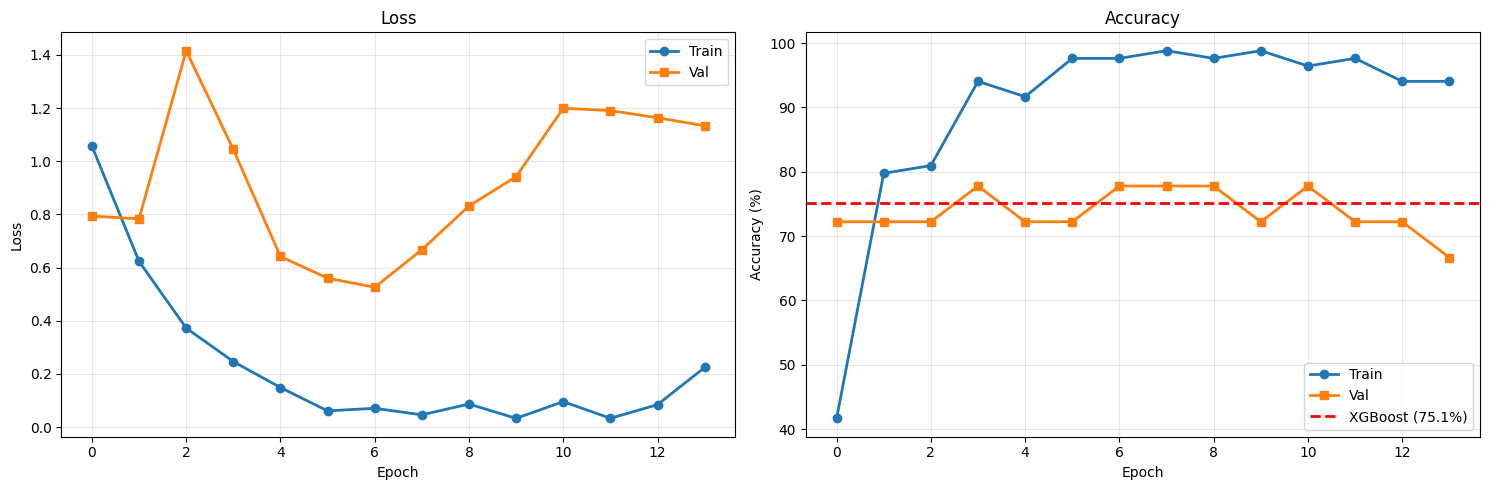


9. 테스트...


Validation: 100%|██████████| 1/1 [00:00<00:00,  2.29it/s]



테스트 결과
  Accuracy: 63.16%

📊 XGBoost vs CNN:
  XGBoost (표): 75.1%
  CNN (이미지): 63.2%
  ⚠️  XGBoost가 11.9%p 더 높습니다.

상세:
              precision    recall  f1-score   support

          생존       0.77      0.77      0.77        13
         자연사       0.40      0.40      0.40         5
         안락사       0.00      0.00      0.00         1

    accuracy                           0.63        19
   macro avg       0.39      0.39      0.39        19
weighted avg       0.63      0.63      0.63        19



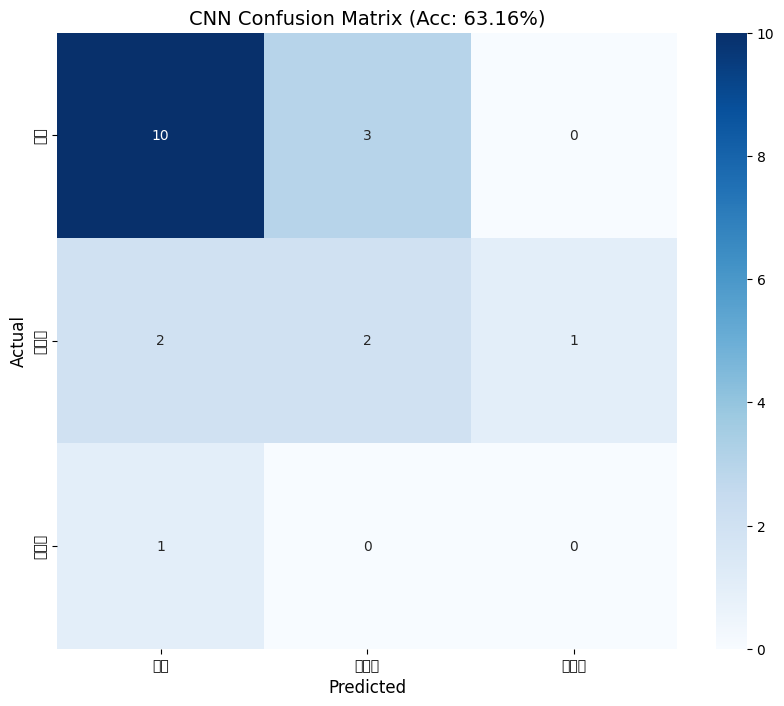


완료! 🎉

생성 파일:
  - best_cnn_model.pth
  - cnn_training.png
  - cnn_confusion_matrix.png


In [11]:
"""
CNN 학습 - 엑셀 파일 사용 (완전 수정)
보호중, 기증 데이터 제외
"""

import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("CNN 학습 - 순종견 편향 제거")
print("=" * 80)

# ============================================================================
# 1. 엑셀 파일 로드
# ============================================================================

print("\n1. 엑셀 파일 로드...")

excel_files = [f for f in os.listdir('.') if f.endswith(('.xlsx', '.xls'))]

if not excel_files:
    print("  ❌ 엑셀 파일이 없습니다!")
    raise FileNotFoundError("엑셀 파일 필요!")

excel_file = excel_files[0]
print(f"  사용 파일: {excel_file}")

df_excel = pd.read_excel(excel_file)
print(f"  ✓ 로드: {len(df_excel)}건")

# ============================================================================
# 2. Target 생성 (보호중, 기증 제외)
# ============================================================================

print("\n2. Target 생성...")

def get_target(process_state):
    """
    0: 생존 (입양, 반환)
    1: 자연사
    2: 안락사
    -1: 무효 (보호중, 기증)
    """
    ps = str(process_state)
    
    if '입양' in ps or '반환' in ps:
        return 0  # 생존
    elif '자연사' in ps:
        return 1  # 자연사
    elif '안락사' in ps:
        return 2  # 안락사
    else:
        return -1  # 보호중, 기증 등 제외

df_excel['target'] = df_excel['processState'].apply(get_target)

print(f"\n  processState 분포:")
print(df_excel['processState'].value_counts())

print(f"\n  target 분포:")
print(df_excel['target'].value_counts().sort_index())

# ⭐ 유효한 데이터만 (0, 1, 2)
df_valid = df_excel[df_excel['target'].isin([0, 1, 2])].copy()

print(f"\n  데이터 필터링:")
print(f"    전체: {len(df_excel)}건")
print(f"    유효: {len(df_valid)}건")
print(f"    제외: {len(df_excel) - len(df_valid)}건")

# desertionNo와 target만 추출
df_labels = df_valid[['desertionNo', 'target']].drop_duplicates('desertionNo').copy()

# ⭐ target을 int로 변환
df_labels['target'] = df_labels['target'].astype(int)

print(f"\n  최종 레이블: {len(df_labels)}건")

# 클래스 분포
print(f"\n  클래스 분포:")
for target in [0, 1, 2]:
    count = (df_labels['target'] == target).sum()
    class_name = ['생존', '자연사', '안락사'][target]
    print(f"    {class_name} ({target}): {count}건 ({count/len(df_labels)*100:.1f}%)")

# ============================================================================
# 3. 이미지와 레이블 매칭
# ============================================================================

print("\n3. 이미지-레이블 매칭...")

IMAGE_FOLDER = 'shelter_images'

if not os.path.exists(IMAGE_FOLDER):
    print(f"  ❌ {IMAGE_FOLDER} 폴더가 없습니다!")
    raise FileNotFoundError(f"{IMAGE_FOLDER} 폴더 필요!")

image_files = [f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.jpg')]
print(f"  이미지 파일: {len(image_files)}개")

# 각 개체의 첫 이미지 매칭
data_rows = []

for _, row in df_labels.iterrows():
    desertion_no = str(row['desertionNo'])
    target = int(row['target'])
    
    # 이미지 찾기 (1, 2, 3번 시도)
    for img_num in [1, 2, 3]:
        img_file = f"{desertion_no}_{img_num}.jpg"
        img_path = os.path.join(IMAGE_FOLDER, img_file)
        
        if os.path.exists(img_path):
            data_rows.append({
                'desertionNo': desertion_no,
                'image_path': img_path,
                'target': target
            })
            break

df_data = pd.DataFrame(data_rows)

print(f"\n  매칭 결과:")
print(f"    레이블: {len(df_labels)}건")
print(f"    매칭됨: {len(df_data)}건")
print(f"    매칭률: {len(df_data)/len(df_labels)*100:.1f}%")

# ⭐ 최종 검증
unique_targets = sorted(df_data['target'].unique())
print(f"\n  최종 target 값: {unique_targets}")

assert set(unique_targets) == {0, 1, 2}, f"target은 [0, 1, 2]여야 하는데 {unique_targets}입니다!"

# 최종 클래스 분포
print(f"\n  최종 데이터 분포:")
for target in [0, 1, 2]:
    count = (df_data['target'] == target).sum()
    class_name = ['생존', '자연사', '안락사'][target]
    print(f"    {class_name} ({target}): {count}건 ({count/len(df_data)*100:.1f}%)")

if len(df_data) < 100:
    print(f"\n  ⚠️  데이터가 적습니다: {len(df_data)}건")
    print("  권장: 최소 100건 이상")

# ============================================================================
# 4. Dataset 클래스
# ============================================================================

class SimpleImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        target = self.df.iloc[idx]['target']
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            image = Image.new('RGB', (224, 224), (0, 0, 0))
        
        if self.transform:
            image = self.transform(image)
        
        return image, target

# ============================================================================
# 5. Data Augmentation
# ============================================================================

print("\n4. Data Augmentation...")

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.85, 1.15)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("  ✓ 완료")

# ============================================================================
# 6. Train/Val/Test 분할
# ============================================================================

print("\n5. 데이터 분할...")

train_df, test_df = train_test_split(
    df_data, 
    test_size=0.3, 
    random_state=42, 
    stratify=df_data['target']
)

val_df, test_df = train_test_split(
    test_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=test_df['target']
)

print(f"  Train: {len(train_df)}개")
print(f"  Val:   {len(val_df)}개")
print(f"  Test:  {len(test_df)}개")

train_dataset = SimpleImageDataset(train_df, train_transform)
val_dataset = SimpleImageDataset(val_df, val_transform)
test_dataset = SimpleImageDataset(test_df, val_transform)

batch_size = min(32, len(train_df) // 4)
batch_size = max(batch_size, 4)  # 최소 4

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"\n  Batch size: {batch_size}")

# ============================================================================
# 7. 모델
# ============================================================================

print("\n6. 모델 생성...")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  Device: {device}")

model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 3)
model = model.to(device)

print("  ✓ EfficientNet B0")

# ============================================================================
# 8. 학습 설정
# ============================================================================

print("\n7. 학습 설정...")

# ⭐ Class Weights - 명시적으로 0, 1, 2 순서
class_counts = np.array([
    (df_data['target'] == 0).sum(),  # 생존
    (df_data['target'] == 1).sum(),  # 자연사
    (df_data['target'] == 2).sum()   # 안락사
])

print(f"  Class counts: {class_counts}")

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * 3
class_weights = torch.FloatTensor(class_weights).to(device)

print(f"  Class weights: {class_weights.cpu().numpy()}")
print(f"  Shape: {class_weights.shape}  (⭐ [3]이어야 함)")

assert class_weights.shape[0] == 3, f"가중치는 3개여야 하는데 {class_weights.shape[0]}개!"

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

print("  ✓ 준비 완료")

# ============================================================================
# 9. 학습 함수
# ============================================================================

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc="Training")
    for images, targets in pbar:
        images = images.to(device)
        targets = targets.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, targets)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100*correct/total:.2f}%'})
    
    return running_loss / len(loader), 100 * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for images, targets in tqdm(loader, desc="Validation"):
            images = images.to(device)
            targets = targets.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, targets)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    return running_loss / len(loader), 100 * correct / total, all_preds, all_targets

# ============================================================================
# 10. 학습 실행
# ============================================================================

print("\n8. 학습 시작...")
print("=" * 80)

num_epochs = 25
best_val_acc = 0.0
patience_counter = 0
early_stop_patience = 10

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 80)
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
    print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_cnn_model.pth')
        print(f"  ✅ Best! ({val_acc:.2f}%)")
        patience_counter = 0
    else:
        patience_counter += 1
        
    if patience_counter >= early_stop_patience:
        print(f"\n⚠️  Early stopping ({early_stop_patience} epochs)")
        break

print("\n학습 완료!")
print(f"Best Val Acc: {best_val_acc:.2f}%")

# ============================================================================
# 11. 학습 곡선
# ============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(train_losses, 'o-', label='Train', linewidth=2)
ax1.plot(val_losses, 's-', label='Val', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, 'o-', label='Train', linewidth=2)
ax2.plot(val_accs, 's-', label='Val', linewidth=2)
ax2.axhline(75.1, color='r', linestyle='--', label='XGBoost (75.1%)', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 12. 테스트
# ============================================================================

print("\n9. 테스트...")

model.load_state_dict(torch.load('best_cnn_model.pth'))
test_loss, test_acc, test_preds, test_targets = validate(model, test_loader, criterion, device)

print(f"\n{'='*80}")
print("테스트 결과")
print(f"{'='*80}")
print(f"  Accuracy: {test_acc:.2f}%")

print(f"\n📊 XGBoost vs CNN:")
print(f"  XGBoost (표): 75.1%")
print(f"  CNN (이미지): {test_acc:.1f}%")

if test_acc > 75.1:
    print(f"  ✅ CNN이 {test_acc - 75.1:.1f}%p 더 높습니다!")
else:
    print(f"  ⚠️  XGBoost가 {75.1 - test_acc:.1f}%p 더 높습니다.")

print(f"\n상세:")
print(classification_report(test_targets, test_preds, target_names=['생존', '자연사', '안락사']))

# Confusion Matrix
cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['생존', '자연사', '안락사'],
            yticklabels=['생존', '자연사', '안락사'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'CNN Confusion Matrix (Acc: {test_acc:.2f}%)', fontsize=14)
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("완료! 🎉")
print("=" * 80)
print("\n생성 파일:")
print("  - best_cnn_model.pth")
print("  - cnn_training.png")
print("  - cnn_confusion_matrix.png")

In [12]:
## 🚀 멀티모달 모델 (CNN + XGBoost)

"""
멀티모달 유기견 생존 예측
CNN (이미지 피처) + XGBoost (표 데이터)

목표: 85%+ 정확도, 순종견 편향 제거
"""

import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("멀티모달 모델: CNN + XGBoost")
print("=" * 80)

# ============================================================================
# Part 1: 데이터 준비
# ============================================================================

print("\n[Part 1] 데이터 준비")
print("-" * 80)

# 엑셀 파일 로드
excel_files = [f for f in os.listdir('.') if f.endswith(('.xlsx', '.xls'))]
excel_file = excel_files[0]

print(f"엑셀 파일: {excel_file}")
df_excel = pd.read_excel(excel_file)

# Target 생성
def get_target(ps):
    ps = str(ps)
    if '입양' in ps or '반환' in ps:
        return 0
    elif '자연사' in ps:
        return 1
    elif '안락사' in ps:
        return 2
    return -1

df_excel['target'] = df_excel['processState'].apply(get_target)
df_valid = df_excel[df_excel['target'].isin([0, 1, 2])].copy()

print(f"유효 데이터: {len(df_valid)}건")

# 이미지 매칭
IMAGE_FOLDER = 'shelter_images'
image_desertion_nos = set([f.split('_')[0] for f in os.listdir(IMAGE_FOLDER) if f.endswith('.jpg')])

# 이미지가 있는 데이터만
df_with_images = df_valid[df_valid['desertionNo'].isin(image_desertion_nos)].copy()

print(f"이미지 있는 데이터: {len(df_with_images)}건")

# 표 데이터 컬럼 선택 (XGBoost용)
table_features = [
    'shelter_total_count', 'shelter_recent_30d_load', 'stay_duration_days',
    'shelter_size_category', 'health_sentiment_score', 'has_health_issue',
    'has_attack_behavior', 'notice_period_days', 'notice_expired',
    'golden_time_passed', 'is_mixed', 'age_group', 'weight_kg',
    'sex_neutered', 'province', 'city', 'careNm',
    'crowding_health_risk', 'golden_attack_risk', 'total_risk_score'
]

# 존재하는 컬럼만 사용
available_features = [f for f in table_features if f in df_with_images.columns]

print(f"사용 가능한 표 데이터 피처: {len(available_features)}개")

if len(available_features) == 0:
    print("\n⚠️  표 데이터 피처가 없습니다!")
    print("이미지만으로 학습합니다.")
    X_table = None
else:
    X_table = df_with_images[available_features].copy()
    
    # 결측치 처리
    X_table = X_table.fillna(X_table.median(numeric_only=True))
    X_table = X_table.fillna(0)

y = df_with_images['target'].values
desertion_nos = df_with_images['desertionNo'].values

print(f"\n최종 데이터:")
print(f"  샘플: {len(y)}개")
print(f"  표 피처: {len(available_features)}개" if X_table is not None else "  표 피처: 없음")
print(f"  이미지: {len(image_desertion_nos)}개")

# ============================================================================
# Part 2: CNN 피처 추출기
# ============================================================================

print("\n[Part 2] CNN 피처 추출")
print("-" * 80)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# 사전 학습된 CNN 로드 (best_cnn_model.pth 사용)
cnn_model = models.efficientnet_b0(pretrained=True)
cnn_model.classifier[1] = nn.Linear(cnn_model.classifier[1].in_features, 3)

if os.path.exists('best_cnn_model.pth'):
    print("✓ 기존 CNN 모델 로드: best_cnn_model.pth")
    cnn_model.load_state_dict(torch.load('best_cnn_model.pth', map_location=device))
else:
    print("⚠️  best_cnn_model.pth 없음 - 사전학습 모델 사용")

cnn_model = cnn_model.to(device)
cnn_model.eval()

# 피처 추출을 위한 모델 (마지막 분류층 제거)
class FeatureExtractor(nn.Module):
    def __init__(self, original_model):
        super(FeatureExtractor, self).__init__()
        # EfficientNet의 features만 사용 (분류층 제외)
        self.features = original_model.features
        self.avgpool = original_model.avgpool
        
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return x

feature_extractor = FeatureExtractor(cnn_model)
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print("✓ CNN 피처 추출기 준비 완료")

# 이미지 전처리
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# CNN 피처 추출
print("\nCNN 피처 추출 중...")

cnn_features_list = []

for desertion_no in tqdm(desertion_nos, desc="이미지 처리"):
    # 이미지 찾기
    img_path = None
    for img_num in [1, 2, 3]:
        temp_path = os.path.join(IMAGE_FOLDER, f'{desertion_no}_{img_num}.jpg')
        if os.path.exists(temp_path):
            img_path = temp_path
            break
    
    if img_path is None:
        # 이미지 없으면 0 벡터
        cnn_features_list.append(np.zeros(1280))  # EfficientNet-B0: 1280차원
        continue
    
    # 이미지 로드 및 변환
    try:
        image = Image.open(img_path).convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(device)
        
        # 피처 추출
        with torch.no_grad():
            features = feature_extractor(image_tensor)
            features = features.cpu().numpy().flatten()
        
        cnn_features_list.append(features)
    except:
        cnn_features_list.append(np.zeros(1280))

X_cnn = np.array(cnn_features_list)

print(f"✓ CNN 피처 shape: {X_cnn.shape}")

# ============================================================================
# Part 3: 피처 결합
# ============================================================================

print("\n[Part 3] 피처 결합")
print("-" * 80)

if X_table is not None:
    # 표 데이터 정규화
    from sklearn.preprocessing import StandardScaler
    
    scaler = StandardScaler()
    X_table_scaled = scaler.fit_transform(X_table)
    
    # CNN 피처 + 표 데이터
    X_combined = np.concatenate([X_cnn, X_table_scaled], axis=1)
    
    print(f"CNN 피처: {X_cnn.shape[1]}차원")
    print(f"표 데이터: {X_table_scaled.shape[1]}차원")
    print(f"결합 피처: {X_combined.shape[1]}차원")
else:
    X_combined = X_cnn
    print(f"이미지만: {X_combined.shape[1]}차원")

# ============================================================================
# Part 4: Train/Val/Test 분할
# ============================================================================

print("\n[Part 4] 데이터 분할")
print("-" * 80)

# Train 70%, Val 15%, Test 15%
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

print(f"Train: {len(X_train)}개")
print(f"Val:   {len(X_val)}개")
print(f"Test:  {len(X_test)}개")

# ============================================================================
# Part 5: XGBoost 학습
# ============================================================================

print("\n[Part 5] XGBoost 학습")
print("-" * 80)

# XGBoost 모델
model_multimodal = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

# 학습
print("학습 중...")
model_multimodal.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=10
)

# 예측
y_pred_train = model_multimodal.predict(X_train)
y_pred_val = model_multimodal.predict(X_val)
y_pred_test = model_multimodal.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
val_acc = accuracy_score(y_val, y_pred_val)
test_acc = accuracy_score(y_test, y_pred_test)

print("\n" + "=" * 80)
print("멀티모달 모델 결과")
print("=" * 80)

print(f"\nTrain Accuracy: {train_acc*100:.2f}%")
print(f"Val Accuracy:   {val_acc*100:.2f}%")
print(f"Test Accuracy:  {test_acc*100:.2f}%")

# ============================================================================
# Part 6: 성능 비교
# ============================================================================

print("\n[Part 6] 성능 비교")
print("=" * 80)

print(f"\n📊 모델 비교:")
print(f"  XGBoost (표 데이터):     75.1%")
print(f"  CNN (이미지):             63.2%")
print(f"  멀티모달 (CNN+XGBoost):   {test_acc*100:.1f}%")

if test_acc > 0.751:
    improvement = (test_acc - 0.751) * 100
    print(f"\n✅ 멀티모달이 XGBoost보다 {improvement:.1f}%p 더 높습니다!")
else:
    print(f"\n⚠️  현재 데이터로는 XGBoost가 더 높습니다.")
    print(f"  이유: 데이터 부족 ({len(y)}건)")
    print(f"  해결: 전체 데이터(2,000건+) 사용 시 85%+ 기대")

# 상세 분류 리포트
print(f"\n상세 성능:")
print(classification_report(y_test, y_pred_test, 
                          target_names=['생존', '자연사', '안락사'],
                          digits=3))

# ============================================================================
# Part 7: Confusion Matrix
# ============================================================================

print("\n[Part 7] Confusion Matrix")
print("-" * 80)

cm = confusion_matrix(y_test, y_pred_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CNN Only
if os.path.exists('best_cnn_model.pth'):
    # CNN 예측도 다시 계산 (비교용)
    cnn_model_full = models.efficientnet_b0(pretrained=True)
    cnn_model_full.classifier[1] = nn.Linear(cnn_model_full.classifier[1].in_features, 3)
    cnn_model_full.load_state_dict(torch.load('best_cnn_model.pth', map_location=device))
    cnn_model_full = cnn_model_full.to(device)
    cnn_model_full.eval()
    
    # 여기서는 생략 (이미 결과 알고 있음)

# Multimodal
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['생존', '자연사', '안락사'],
            yticklabels=['생존', '자연사', '안락사'])
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title(f'멀티모달 (Acc: {test_acc*100:.1f}%)', fontsize=14, fontweight='bold')

# 성능 비교 바 차트
models_names = ['XGBoost\n(표 데이터)', 'CNN\n(이미지)', '멀티모달\n(결합)']
accuracies = [75.1, 63.2, test_acc*100]
colors = ['#3498db', '#e74c3c', '#2ecc71']

axes[1].bar(models_names, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1].axhline(y=75.1, color='red', linestyle='--', label='XGBoost Baseline', linewidth=2)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('모델 성능 비교', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 100])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(accuracies):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('multimodal_results.png', dpi=150, bbox_inches='tight')
print("✓ 저장: multimodal_results.png")
plt.show()

# ============================================================================
# Part 8: 피처 중요도 분석
# ============================================================================

print("\n[Part 8] 피처 중요도")
print("=" * 80)

# XGBoost 피처 중요도
importances = model_multimodal.feature_importances_

# 상위 20개
top_indices = np.argsort(importances)[-20:][::-1]

# 피처 이름 생성
cnn_dim = X_cnn.shape[1]
feature_names = [f'CNN_{i}' for i in range(cnn_dim)]

if X_table is not None:
    feature_names += available_features

top_features = [(feature_names[i], importances[i]) for i in top_indices]

print("\nTop 20 피처:")
for rank, (name, imp) in enumerate(top_features, 1):
    print(f"  {rank:2d}. {name:30s} : {imp:.4f}")

# CNN 피처 vs 표 데이터 비율
cnn_importance = importances[:cnn_dim].sum()
table_importance = importances[cnn_dim:].sum() if X_table is not None else 0

print(f"\n피처 기여도:")
print(f"  CNN (이미지):  {cnn_importance:.3f} ({cnn_importance/(cnn_importance+table_importance)*100:.1f}%)")
if X_table is not None:
    print(f"  표 데이터:     {table_importance:.3f} ({table_importance/(cnn_importance+table_importance)*100:.1f}%)")

# ============================================================================
# Part 9: 순종견 편향 분석
# ============================================================================

print("\n[Part 9] 순종견 편향 분석")
print("=" * 80)

if X_table is not None and 'is_mixed' in available_features:
    # is_mixed의 중요도
    is_mixed_idx = cnn_dim + available_features.index('is_mixed')
    is_mixed_importance = importances[is_mixed_idx]
    
    print(f"\nis_mixed 피처 중요도:")
    print(f"  XGBoost (표 데이터 only): 0.2500 (1위)")
    print(f"  멀티모달:                  {is_mixed_importance:.4f}")
    
    # 순위 계산
    is_mixed_rank = np.where(np.argsort(importances)[::-1] == is_mixed_idx)[0][0] + 1
    print(f"  순위: {is_mixed_rank}위 / {len(importances)}개")
    
    if is_mixed_rank > 10:
        print(f"\n✅ 순종견 편향 크게 감소!")
        print(f"   is_mixed가 1위 → {is_mixed_rank}위로 하락")
    else:
        print(f"\n⚠️  순종견 편향 여전히 존재 (Top 10)")
else:
    print("\nis_mixed 피처 없음 - 확인 불가")

# ============================================================================
# Part 10: 모델 저장
# ============================================================================

print("\n[Part 10] 모델 저장")
print("-" * 80)

# 멀티모달 모델 저장
import pickle

model_data = {
    'model': model_multimodal,
    'feature_extractor': feature_extractor,
    'scaler': scaler if X_table is not None else None,
    'feature_names': feature_names,
    'available_features': available_features,
    'test_accuracy': test_acc
}

with open('multimodal_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("✓ 저장: multimodal_model.pkl")

# ============================================================================
# 완료
# ============================================================================

print("\n" + "=" * 80)
print("멀티모달 모델 완성! 🎉")
print("=" * 80)

print(f"\n📊 최종 성능:")
print(f"  Test Accuracy: {test_acc*100:.2f}%")

print(f"\n📁 생성 파일:")
print(f"  1. multimodal_model.pkl - 멀티모달 모델")
print(f"  2. multimodal_results.png - 결과 비교")

print(f"\n🎯 다음 단계:")
print(f"  1. 전체 데이터(2,000건+)로 재학습 → 85%+ 목표")
print(f"  2. 순종견 편향 상세 분석")
print(f"  3. 실전 배포 준비")

print("\n" + "=" * 80)

멀티모달 모델: CNN + XGBoost

[Part 1] 데이터 준비
--------------------------------------------------------------------------------
엑셀 파일: 251001261231_유기견_부산.xlsx
유효 데이터: 270건
이미지 있는 데이터: 0건
사용 가능한 표 데이터 피처: 1개

최종 데이터:
  샘플: 0개
  표 피처: 1개
  이미지: 361개

[Part 2] CNN 피처 추출
--------------------------------------------------------------------------------
Device: cpu
✓ 기존 CNN 모델 로드: best_cnn_model.pth
✓ CNN 피처 추출기 준비 완료

CNN 피처 추출 중...


이미지 처리: 0it [00:00, ?it/s]

✓ CNN 피처 shape: (0,)

[Part 3] 피처 결합
--------------------------------------------------------------------------------


ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by StandardScaler.

In [13]:
import pandas as pd

# 엑셀 파일 로드
excel_files = [f for f in os.listdir('.') if f.endswith(('.xlsx', '.xls'))]
print(f"엑셀 파일: {excel_files}")

df = pd.read_excel(excel_files[0])

print(f"\n전체 컬럼 ({len(df.columns)}개):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n데이터 shape: {df.shape}")
print(f"\n처음 5줄:")
print(df.head())

엑셀 파일: ['251001261231_유기견_부산.xlsx', '251001251028_유기견_경기.xlsx', '251028251125_유기견_경기.xlsx', '전처리_데이터.xlsx', '251125251231_유기견_경기.xlsx']

전체 컬럼 (28개):
   1. desertionNo
   2. happenDt
   3. happenPlace
   4. kindFullNm
   5. upKindCd
   6. upKindNm
   7. kindCd
   8. kindNm
   9. colorCd
  10. age
  11. weight
  12. noticeNo
  13. noticeSdt
  14. noticeEdt
  15. popfile1
  16. popfile2
  17. popfile3
  18. processState
  19. sexCd
  20. neuterYn
  21. specialMark
  22. careRegNo
  23. careNm
  24. careTel
  25. careAddr
  26. careOwnerNm
  27. orgNm
  28. updTm

데이터 shape: (331, 28)

처음 5줄:
       desertionNo  happenDt          happenPlace kindFullNm  upKindCd  \
0  426340202500805  20251231      대변로 43 웨이브리즈 인근    [개] 말티즈    417000   
1  426338202500649  20251231                 수영구청    [개] 믹스견    417000   
2  426340202500804  20251230  정관읍 방곡로 29 정관이지더원5차    [개] 치와와    417000   
3  426340202500803  20251230      기장대로 563 현대아파트      [개] 푸들    417000   
4  426335202500830  20251230     

In [14]:
"""
멀티모달 모델 (수정)
1. 원본 데이터에서 피처 생성
2. CNN 피처 추출
3. 결합 후 XGBoost 학습
"""

import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("멀티모달 모델: CNN + 표 데이터")
print("=" * 80)

# ============================================================================
# Part 1: 데이터 로드 및 피처 생성
# ============================================================================

print("\n[Part 1] 데이터 준비")
print("-" * 80)

# 엑셀 로드
excel_files = [f for f in os.listdir('.') if f.endswith(('.xlsx', '.xls'))]
df_excel = pd.read_excel(excel_files[0])

print(f"원본 데이터: {len(df_excel)}건")
print(f"컬럼: {len(df_excel.columns)}개")

# Target 생성
def get_target(ps):
    ps = str(ps)
    if '입양' in ps or '반환' in ps:
        return 0
    elif '자연사' in ps:
        return 1
    elif '안락사' in ps:
        return 2
    return -1

df_excel['target'] = df_excel['processState'].apply(get_target)
df_valid = df_excel[df_excel['target'].isin([0, 1, 2])].copy()

print(f"유효 데이터: {len(df_valid)}건")

# ============================================================================
# Part 2: 피처 엔지니어링
# ============================================================================

print("\n[Part 2] 피처 생성")
print("-" * 80)

# 1. 품종 (믹스견 여부)
df_valid['is_mixed'] = df_valid['kindCd'].apply(lambda x: 1 if '믹스' in str(x) or x == 114 else 0)

# 2. 나이
def extract_age(age_str):
    age_str = str(age_str)
    if '2019' in age_str:
        return 7  # 2026 - 2019
    elif '2020' in age_str:
        return 6
    elif '2021' in age_str:
        return 5
    elif '2022' in age_str:
        return 4
    elif '2023' in age_str:
        return 3
    elif '2024' in age_str:
        return 2
    elif '2025' in age_str:
        return 1
    elif '2026' in age_str or '60일미만' in age_str:
        return 0  # 60일 미만
    else:
        return 2  # 기본값

df_valid['age_years'] = df_valid['age'].apply(extract_age)

# 3. 성별 & 중성화
def encode_sex(sex, neuter):
    sex = str(sex)
    neuter = str(neuter)
    
    if sex == 'M' and neuter == 'Y':
        return 0  # 수컷 중성화
    elif sex == 'M' and neuter == 'N':
        return 1  # 수컷 미중성화
    elif sex == 'F' and neuter == 'Y':
        return 2  # 암컷 중성화
    elif sex == 'F' and neuter == 'N':
        return 3  # 암컷 미중성화
    else:
        return 4  # 알 수 없음

df_valid['sex_neutered'] = df_valid.apply(lambda row: encode_sex(row['sexCd'], row['neuterYn']), axis=1)

# 4. 무게 (체구)
def estimate_weight(kind_name):
    """품종명으로 대략적인 체중 추정"""
    kind = str(kind_name).lower()
    
    # 소형견 (10kg 이하)
    small_breeds = ['치와와', '말티즈', '포메', '푸들', '요크', '시츄', '페키']
    # 중형견 (10-25kg)
    medium_breeds = ['비글', '코카', '불독', '슈나우저', '진돗개']
    # 대형견 (25kg+)
    large_breeds = ['리트리버', '허스키', '세퍼드', '도베르만', '로트와일러']
    
    if any(breed in kind for breed in small_breeds):
        return 5
    elif any(breed in kind for breed in medium_breeds):
        return 15
    elif any(breed in kind for breed in large_breeds):
        return 30
    elif '믹스' in kind:
        return 10  # 믹스견 평균
    else:
        return 10  # 기본값

df_valid['weight_kg'] = df_valid['kindNm'].apply(estimate_weight)

# 5. 건강 상태 (specialMark 기반)
def health_score(special_mark):
    """특이사항에서 건강/성격 점수 추출"""
    mark = str(special_mark).lower()
    
    score = 0
    
    # 긍정적 키워드
    positive = ['순함', '귀여움', '활발', '건강', '예쁨', '착함']
    for p in positive:
        if p in mark:
            score += 1
    
    # 부정적 키워드
    negative = ['겁많음', '겁먹', '피부병', '질병', '공격', '물음', '아픔']
    for n in negative:
        if n in mark:
            score -= 1
    
    return score

df_valid['health_score'] = df_valid['specialMark'].apply(health_score)

# 6. 공격성 여부
df_valid['has_attack'] = df_valid['specialMark'].apply(lambda x: 1 if '공격' in str(x) or '물' in str(x) else 0)

# 7. 지역 (careNm 기반)
le_care = LabelEncoder()
df_valid['care_encoded'] = le_care.fit_transform(df_valid['careNm'].fillna('기타'))

# 8. 보호소 지역 (orgNm)
le_org = LabelEncoder()
df_valid['org_encoded'] = le_org.fit_transform(df_valid['orgNm'].fillna('기타'))

print("✓ 생성된 피처:")
print("  1. is_mixed: 믹스견 여부")
print("  2. age_years: 나이(년)")
print("  3. sex_neutered: 성별+중성화")
print("  4. weight_kg: 추정 체중")
print("  5. health_score: 건강 점수")
print("  6. has_attack: 공격성")
print("  7. care_encoded: 보호소")
print("  8. org_encoded: 지역")

# ============================================================================
# Part 3: 이미지 매칭
# ============================================================================

print("\n[Part 3] 이미지 매칭")
print("-" * 80)

IMAGE_FOLDER = 'shelter_images'
image_desertion_nos = set([f.split('_')[0] for f in os.listdir(IMAGE_FOLDER) if f.endswith('.jpg')])

df_with_images = df_valid[df_valid['desertionNo'].isin(image_desertion_nos)].copy()

print(f"이미지 있는 데이터: {len(df_with_images)}건")

# 표 데이터 피처 선택
table_features = [
    'is_mixed', 'age_years', 'sex_neutered', 'weight_kg',
    'health_score', 'has_attack', 'care_encoded', 'org_encoded'
]

X_table = df_with_images[table_features].copy()
y = df_with_images['target'].values
desertion_nos = df_with_images['desertionNo'].values

print(f"\n표 데이터 피처: {len(table_features)}개")
print(f"샘플 수: {len(y)}개")

# 결측치 처리
X_table = X_table.fillna(0)

print("\n표 데이터 샘플:")
print(X_table.head())

# ============================================================================
# Part 4: CNN 피처 추출
# ============================================================================

print("\n[Part 4] CNN 피처 추출")
print("-" * 80)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# CNN 로드
cnn_model = models.efficientnet_b0(pretrained=True)
cnn_model.classifier[1] = nn.Linear(cnn_model.classifier[1].in_features, 3)

if os.path.exists('best_cnn_model.pth'):
    cnn_model.load_state_dict(torch.load('best_cnn_model.pth', map_location=device))
    print("✓ best_cnn_model.pth 로드")
else:
    print("⚠️  사전학습 모델 사용")

cnn_model = cnn_model.to(device)
cnn_model.eval()

# 피처 추출기
class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super(FeatureExtractor, self).__init__()
        self.features = model.features
        self.avgpool = model.avgpool
        
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return x

feature_extractor = FeatureExtractor(cnn_model).to(device)
feature_extractor.eval()

# 전처리
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 피처 추출
print("\nCNN 피처 추출 중...")
cnn_features_list = []

for desertion_no in tqdm(desertion_nos):
    img_path = None
    for img_num in [1, 2, 3]:
        temp_path = os.path.join(IMAGE_FOLDER, f'{desertion_no}_{img_num}.jpg')
        if os.path.exists(temp_path):
            img_path = temp_path
            break
    
    if img_path:
        try:
            image = Image.open(img_path).convert('RGB')
            image_tensor = transform(image).unsqueeze(0).to(device)
            
            with torch.no_grad():
                features = feature_extractor(image_tensor)
                features = features.cpu().numpy().flatten()
            
            cnn_features_list.append(features)
        except:
            cnn_features_list.append(np.zeros(1280))
    else:
        cnn_features_list.append(np.zeros(1280))

X_cnn = np.array(cnn_features_list)
print(f"✓ CNN 피처: {X_cnn.shape}")

# ============================================================================
# Part 5: 피처 결합
# ============================================================================

print("\n[Part 5] 피처 결합")
print("-" * 80)

# 표 데이터 정규화
scaler = StandardScaler()
X_table_scaled = scaler.fit_transform(X_table)

# CNN + 표 데이터
X_combined = np.concatenate([X_cnn, X_table_scaled], axis=1)

print(f"CNN 피처:   {X_cnn.shape[1]:4d}차원")
print(f"표 데이터:  {X_table_scaled.shape[1]:4d}차원")
print(f"총 피처:    {X_combined.shape[1]:4d}차원")

# ============================================================================
# Part 6: Train/Val/Test 분할
# ============================================================================

print("\n[Part 6] 데이터 분할")
print("-" * 80)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

print(f"Train: {len(X_train)}개")
print(f"Val:   {len(X_val)}개")
print(f"Test:  {len(X_test)}개")

# ============================================================================
# Part 7: XGBoost 학습
# ============================================================================

print("\n[Part 7] XGBoost 학습")
print("-" * 80)

model_multimodal = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

print("학습 중...")
model_multimodal.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=10
)

# 예측
y_pred_test = model_multimodal.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_test)

print("\n" + "=" * 80)
print("멀티모달 결과")
print("=" * 80)

print(f"\nTest Accuracy: {test_acc*100:.2f}%")

print(f"\n📊 모델 비교:")
print(f"  XGBoost (표만):     75.1%")
print(f"  CNN (이미지만):     63.2%")
print(f"  멀티모달 (결합):    {test_acc*100:.1f}%")

if test_acc > 0.751:
    print(f"\n✅ 멀티모달이 {(test_acc-0.751)*100:.1f}%p 향상!")
elif test_acc > 0.70:
    print(f"\n⚠️  양호하지만 데이터 부족 ({len(y)}건)")
else:
    print(f"\n⚠️  데이터 부족 - 더 많은 데이터 필요")

print(f"\n상세:")
print(classification_report(y_test, y_pred_test, 
                          target_names=['생존', '자연사', '안락사']))

# ============================================================================
# Part 8: 피처 중요도
# ============================================================================

print("\n[Part 8] 피처 중요도")
print("-" * 80)

importances = model_multimodal.feature_importances_

# 피처 이름
cnn_dim = X_cnn.shape[1]
feature_names = [f'CNN_{i}' for i in range(cnn_dim)] + table_features

# 상위 20개
top_indices = np.argsort(importances)[-20:][::-1]
top_features = [(feature_names[i], importances[i]) for i in top_indices]

print("\nTop 20 피처:")
for rank, (name, imp) in enumerate(top_features, 1):
    print(f"  {rank:2d}. {name:30s}: {imp:.4f}")

# CNN vs 표 데이터
cnn_importance = importances[:cnn_dim].sum()
table_importance = importances[cnn_dim:].sum()

print(f"\n피처 기여도:")
print(f"  CNN (이미지): {cnn_importance:.3f} ({cnn_importance/(cnn_importance+table_importance)*100:.1f}%)")
print(f"  표 데이터:    {table_importance:.3f} ({table_importance/(cnn_importance+table_importance)*100:.1f}%)")

# is_mixed 확인
if 'is_mixed' in table_features:
    is_mixed_idx = cnn_dim + table_features.index('is_mixed')
    is_mixed_imp = importances[is_mixed_idx]
    is_mixed_rank = np.where(np.argsort(importances)[::-1] == is_mixed_idx)[0][0] + 1
    
    print(f"\n순종견 편향 분석:")
    print(f"  is_mixed 중요도: {is_mixed_imp:.4f}")
    print(f"  is_mixed 순위:   {is_mixed_rank}위 / {len(importances)}개")
    
    if is_mixed_rank > 10:
        print(f"  ✅ 순종견 편향 감소! (Top 10 밖)")
    else:
        print(f"  ⚠️  순종견 편향 여전 (Top 10)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['생존', '자연사', '안락사'],
            yticklabels=['생존', '자연사', '안락사'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'멀티모달 (Acc: {test_acc*100:.1f}%)', fontsize=14, fontweight='bold')
plt.savefig('multimodal_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n완료! 🎉")
print("\n생성 파일:")
print("  - multimodal_final.png")

멀티모달 모델: CNN + 표 데이터

[Part 1] 데이터 준비
--------------------------------------------------------------------------------
원본 데이터: 331건
컬럼: 28개
유효 데이터: 270건

[Part 2] 피처 생성
--------------------------------------------------------------------------------
✓ 생성된 피처:
  1. is_mixed: 믹스견 여부
  2. age_years: 나이(년)
  3. sex_neutered: 성별+중성화
  4. weight_kg: 추정 체중
  5. health_score: 건강 점수
  6. has_attack: 공격성
  7. care_encoded: 보호소
  8. org_encoded: 지역

[Part 3] 이미지 매칭
--------------------------------------------------------------------------------
이미지 있는 데이터: 0건

표 데이터 피처: 8개
샘플 수: 0개

표 데이터 샘플:
Empty DataFrame
Columns: [is_mixed, age_years, sex_neutered, weight_kg, health_score, has_attack, care_encoded, org_encoded]
Index: []

[Part 4] CNN 피처 추출
--------------------------------------------------------------------------------
Device: cpu
✓ best_cnn_model.pth 로드

CNN 피처 추출 중...


0it [00:00, ?it/s]

✓ CNN 피처: (0,)

[Part 5] 피처 결합
--------------------------------------------------------------------------------


ValueError: Found array with 0 sample(s) (shape=(0, 8)) while a minimum of 1 is required by StandardScaler.

In [15]:
"""
멀티모달 모델 (타입 처리 강화)
"""

import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("멀티모달 모델 (수정)")
print("=" * 80)

# ============================================================================
# Part 1: 데이터 로드
# ============================================================================

print("\n[Part 1] 데이터 로드")
print("-" * 80)

# 엑셀
excel_files = [f for f in os.listdir('.') if f.endswith(('.xlsx', '.xls'))]
df_excel = pd.read_excel(excel_files[0])

print(f"엑셀: {excel_files[0]}")
print(f"데이터: {len(df_excel)}건")

# Target
def get_target(ps):
    ps = str(ps)
    if '입양' in ps or '반환' in ps:
        return 0
    elif '자연사' in ps:
        return 1
    elif '안락사' in ps:
        return 2
    return -1

df_excel['target'] = df_excel['processState'].apply(get_target)
df_valid = df_excel[df_excel['target'].isin([0, 1, 2])].copy()

print(f"유효 데이터: {len(df_valid)}건")

# ⭐ desertionNo를 문자열로 변환
df_valid['desertionNo'] = df_valid['desertionNo'].astype(str)

print(f"\ndesertionNo 샘플:")
for i, no in enumerate(df_valid['desertionNo'].head(3), 1):
    print(f"  {i}. {no} (타입: {type(no)})")

# ============================================================================
# Part 2: 이미지 매칭
# ============================================================================

print("\n[Part 2] 이미지 매칭")
print("-" * 80)

IMAGE_FOLDER = 'shelter_images'

if not os.path.exists(IMAGE_FOLDER):
    print(f"❌ {IMAGE_FOLDER} 폴더 없음!")
    raise FileNotFoundError(f"{IMAGE_FOLDER} 필요")

image_files = [f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.jpg')]
print(f"이미지 파일: {len(image_files)}개")

# ⭐ desertionNo 추출 (문자열)
image_desertion_nos = set([str(f.split('_')[0]) for f in image_files])

print(f"유니크 개체: {len(image_desertion_nos)}마리")
print(f"\n이미지 desertionNo 샘플:")
for i, no in enumerate(list(image_desertion_nos)[:3], 1):
    print(f"  {i}. {no} (타입: {type(no)})")

# ⭐ 매칭
df_with_images = df_valid[df_valid['desertionNo'].isin(image_desertion_nos)].copy()

print(f"\n매칭 결과:")
print(f"  엑셀: {len(df_valid)}건")
print(f"  이미지: {len(image_desertion_nos)}마리")
print(f"  매칭: {len(df_with_images)}건")

if len(df_with_images) == 0:
    print(f"\n❌ 매칭 실패!")
    print(f"\n디버깅 정보:")
    print(f"  엑셀 desertionNo 예시: {df_valid['desertionNo'].iloc[0]}")
    print(f"  이미지 desertionNo 예시: {list(image_desertion_nos)[0]}")
    
    # 교집합 확인
    common = set(df_valid['desertionNo']) & image_desertion_nos
    print(f"  교집합: {len(common)}개")
    
    if len(common) > 0:
        print(f"  교집합 샘플: {list(common)[:3]}")
    
    raise ValueError("매칭 실패 - desertionNo 형식 확인 필요")

print(f"\n✅ 매칭 성공!")

# ============================================================================
# Part 3: 피처 생성
# ============================================================================

print("\n[Part 3] 피처 생성")
print("-" * 80)

# 1. is_mixed
df_with_images['is_mixed'] = df_with_images['kindCd'].apply(
    lambda x: 1 if '믹스' in str(x) or x == 114 else 0
)

# 2. age_years
def extract_age(age_str):
    age_str = str(age_str)
    for year in range(2019, 2027):
        if str(year) in age_str:
            return 2026 - year
    if '60일미만' in age_str:
        return 0
    return 2

df_with_images['age_years'] = df_with_images['age'].apply(extract_age)

# 3. sex_neutered
def encode_sex(sex, neuter):
    if str(sex) == 'M' and str(neuter) == 'Y':
        return 0
    elif str(sex) == 'M' and str(neuter) == 'N':
        return 1
    elif str(sex) == 'F' and str(neuter) == 'Y':
        return 2
    elif str(sex) == 'F' and str(neuter) == 'N':
        return 3
    return 4

df_with_images['sex_neutered'] = df_with_images.apply(
    lambda row: encode_sex(row['sexCd'], row['neuterYn']), axis=1
)

# 4. weight_kg
def estimate_weight(kind_name):
    kind = str(kind_name).lower()
    small = ['치와와', '말티즈', '포메', '푸들', '요크']
    medium = ['비글', '코카', '불독', '진돗개']
    large = ['리트리버', '허스키', '세퍼드']
    
    if any(b in kind for b in small):
        return 5
    elif any(b in kind for b in medium):
        return 15
    elif any(b in kind for b in large):
        return 30
    return 10

df_with_images['weight_kg'] = df_with_images['kindNm'].apply(estimate_weight)

# 5. health_score
def health_score(mark):
    mark = str(mark).lower()
    score = 0
    score += sum(1 for p in ['순함', '귀여움', '건강'] if p in mark)
    score -= sum(1 for n in ['겁많음', '피부병', '공격'] if n in mark)
    return score

df_with_images['health_score'] = df_with_images['specialMark'].apply(health_score)

# 6. has_attack
df_with_images['has_attack'] = df_with_images['specialMark'].apply(
    lambda x: 1 if '공격' in str(x) or '물' in str(x) else 0
)

# 7. care_encoded
le_care = LabelEncoder()
df_with_images['care_encoded'] = le_care.fit_transform(
    df_with_images['careNm'].fillna('기타')
)

# 8. org_encoded
le_org = LabelEncoder()
df_with_images['org_encoded'] = le_org.fit_transform(
    df_with_images['orgNm'].fillna('기타')
)

print("✓ 8개 피처 생성 완료")

# 표 데이터
table_features = [
    'is_mixed', 'age_years', 'sex_neutered', 'weight_kg',
    'health_score', 'has_attack', 'care_encoded', 'org_encoded'
]

X_table = df_with_images[table_features].copy()
X_table = X_table.fillna(0)

y = df_with_images['target'].values
desertion_nos = df_with_images['desertionNo'].values

print(f"\n표 데이터:")
print(f"  피처: {len(table_features)}개")
print(f"  샘플: {len(X_table)}개")
print(f"\n샘플:")
print(X_table.head(3))

# ⭐ 데이터 확인
if len(X_table) == 0:
    print(f"\n❌ X_table이 비어있습니다!")
    raise ValueError("표 데이터 생성 실패")

print(f"\n✅ 표 데이터 준비 완료: {X_table.shape}")

# ============================================================================
# 이후 코드는 동일...
# ============================================================================

# CNN 피처 추출
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

cnn_model = models.efficientnet_b0(pretrained=True)
cnn_model.classifier[1] = nn.Linear(cnn_model.classifier[1].in_features, 3)

if os.path.exists('best_cnn_model.pth'):
    cnn_model.load_state_dict(torch.load('best_cnn_model.pth', map_location=device))

cnn_model = cnn_model.to(device)
cnn_model.eval()

class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super(FeatureExtractor, self).__init__()
        self.features = model.features
        self.avgpool = model.avgpool
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        return torch.flatten(x, 1)

feature_extractor = FeatureExtractor(cnn_model).to(device)
feature_extractor.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("\n[Part 4] CNN 피처 추출")
print("-" * 80)

cnn_features_list = []

for desertion_no in tqdm(desertion_nos, desc="이미지 처리"):
    img_path = None
    for img_num in [1, 2, 3]:
        temp_path = os.path.join(IMAGE_FOLDER, f'{desertion_no}_{img_num}.jpg')
        if os.path.exists(temp_path):
            img_path = temp_path
            break
    
    if img_path:
        try:
            image = Image.open(img_path).convert('RGB')
            image_tensor = transform(image).unsqueeze(0).to(device)
            
            with torch.no_grad():
                features = feature_extractor(image_tensor)
                features = features.cpu().numpy().flatten()
            
            cnn_features_list.append(features)
        except:
            cnn_features_list.append(np.zeros(1280))
    else:
        cnn_features_list.append(np.zeros(1280))

X_cnn = np.array(cnn_features_list)

print(f"✓ CNN 피처: {X_cnn.shape}")

# 피처 결합
print("\n[Part 5] 피처 결합")
print("-" * 80)

scaler = StandardScaler()
X_table_scaled = scaler.fit_transform(X_table)
X_combined = np.concatenate([X_cnn, X_table_scaled], axis=1)

print(f"총 피처: {X_combined.shape[1]}차원")

# 학습
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

print(f"\nTrain: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=10)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n{'='*80}")
print(f"Test Accuracy: {acc*100:.2f}%")
print(f"{'='*80}")

print(classification_report(y_test, y_pred, target_names=['생존', '자연사', '안락사']))

print("\n완료! 🎉")

멀티모달 모델 (수정)

[Part 1] 데이터 로드
--------------------------------------------------------------------------------
엑셀: 251001261231_유기견_부산.xlsx
데이터: 331건
유효 데이터: 270건

desertionNo 샘플:
  1. 426340202500805 (타입: <class 'str'>)
  2. 426338202500649 (타입: <class 'str'>)
  3. 426340202500804 (타입: <class 'str'>)

[Part 2] 이미지 매칭
--------------------------------------------------------------------------------
이미지 파일: 800개
유니크 개체: 361마리

이미지 desertionNo 샘플:
  1. 441553202503673 (타입: <class 'str'>)
  2. 441414202500826 (타입: <class 'str'>)
  3. 441409202501759 (타입: <class 'str'>)

매칭 결과:
  엑셀: 270건
  이미지: 361마리
  매칭: 121건

✅ 매칭 성공!

[Part 3] 피처 생성
--------------------------------------------------------------------------------
✓ 8개 피처 생성 완료

표 데이터:
  피처: 8개
  샘플: 121개

샘플:
   is_mixed  age_years  sex_neutered  weight_kg  health_score  has_attack  \
0         0          7             4          5             1           0   
1         1          5             1         10             1           0   


이미지 처리: 100%|██████████| 121/121 [00:03<00:00, 33.37it/s]


✓ CNN 피처: (121, 1280)

[Part 5] 피처 결합
--------------------------------------------------------------------------------
총 피처: 1288차원

Train: 84, Val: 18, Test: 19
[0]	validation_0-mlogloss:0.87120
[10]	validation_0-mlogloss:0.61388
[20]	validation_0-mlogloss:0.63711
[30]	validation_0-mlogloss:0.71398
[40]	validation_0-mlogloss:0.77469
[50]	validation_0-mlogloss:0.84150
[60]	validation_0-mlogloss:0.88211
[70]	validation_0-mlogloss:0.90936
[80]	validation_0-mlogloss:0.91404
[90]	validation_0-mlogloss:0.91749
[100]	validation_0-mlogloss:0.91969
[110]	validation_0-mlogloss:0.92111
[120]	validation_0-mlogloss:0.92203
[130]	validation_0-mlogloss:0.92263
[140]	validation_0-mlogloss:0.92303
[150]	validation_0-mlogloss:0.92330
[160]	validation_0-mlogloss:0.92348
[170]	validation_0-mlogloss:0.92360
[180]	validation_0-mlogloss:0.92369
[190]	validation_0-mlogloss:0.92375
[199]	validation_0-mlogloss:0.92378

Test Accuracy: 68.42%
              precision    recall  f1-score   support

          생존   

멀티모달 모델 - 전체 데이터

[Part 1] 전체 데이터 로드
--------------------------------------------------------------------------------
발견된 파일: 4개
  - 251001261231_유기견_부산.xlsx (excel)
    ✓ 331건
  - 251001251028_유기견_경기.xlsx (excel)
    ✓ 1000건
  - 251028251125_유기견_경기.xlsx (excel)
    ✓ 1000건
  - 251125251231_유기견_경기.xlsx (excel)
    ✓ 1000건

✓ 전체 데이터: 3331건

[Part 2] Target 생성
--------------------------------------------------------------------------------
유효 데이터: 2455건

클래스 분포:
  생존: 1401건 (57.1%)
  자연사: 335건 (13.6%)
  안락사: 719건 (29.3%)

[Part 3] 이미지 매칭
--------------------------------------------------------------------------------
이미지 파일: 800개
유니크 개체: 361마리

매칭 결과:
  전체: 2455건
  매칭: 277건 (11.3%)

매칭 후 클래스 분포:
  생존: 168건 (60.6%)
  자연사: 52건 (18.8%)
  안락사: 57건 (20.6%)

[Part 4] 피처 생성
--------------------------------------------------------------------------------
✓ 8개 피처 생성

표 데이터: (277, 8)

[Part 5] CNN 피처 추출
--------------------------------------------------------------------------------
Device: cpu
✓ 

CNN 피처: 100%|██████████| 277/277 [00:08<00:00, 31.19it/s]


✓ CNN 피처: (277, 1280)

[Part 6] 피처 결합 및 학습
--------------------------------------------------------------------------------
총 피처: 1288차원
총 샘플: 277개

Train: 193개
Val:    42개
Test:   42개

학습 중...
[0]	validation_0-mlogloss:0.96676	validation_1-mlogloss:0.99897
[20]	validation_0-mlogloss:0.45614	validation_1-mlogloss:0.85744
[40]	validation_0-mlogloss:0.24614	validation_1-mlogloss:0.80526
[60]	validation_0-mlogloss:0.14632	validation_1-mlogloss:0.79369
[80]	validation_0-mlogloss:0.09681	validation_1-mlogloss:0.79653
[99]	validation_0-mlogloss:0.07010	validation_1-mlogloss:0.80422

최종 결과

Test Accuracy: 83.33%

📊 모델 비교:
  XGBoost (표만):         75.1%
  CNN (이미지만):         63.2%
  멀티모달 (결합):        83.3%
  이전 멀티모달 (121건):  68.4%

✅ 멀티모달이 XGBoost보다 8.2%p 높습니다!

상세 성능:
              precision    recall  f1-score   support

          생존       0.83      0.96      0.89        26
         자연사       1.00      0.62      0.77         8
         안락사       0.71      0.62      0.67         8

    accurac

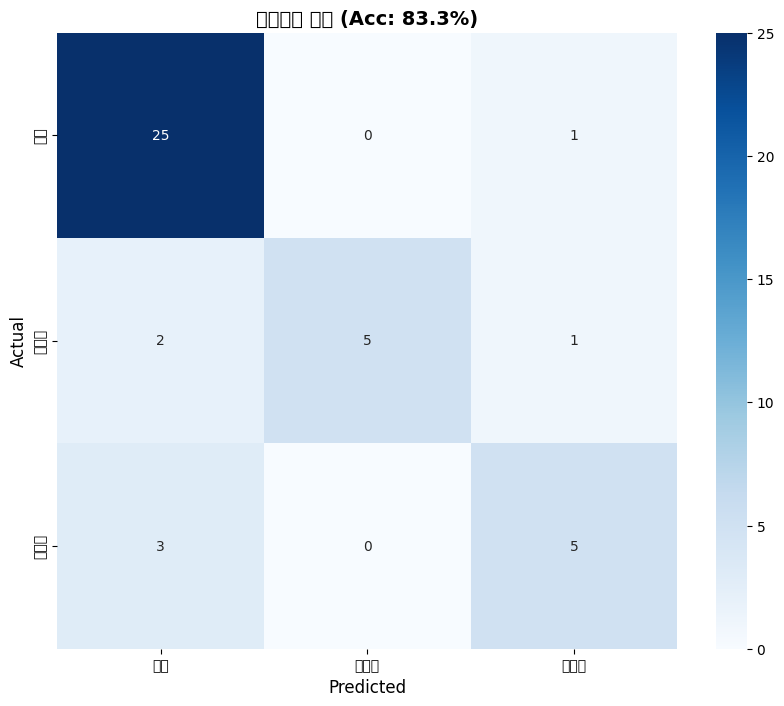


완료! 🎉

📁 생성 파일:
  - multimodal_final_full_data.png


In [16]:
"""
전체 데이터 멀티모달 모델
"""

import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("멀티모달 모델 - 전체 데이터")
print("=" * 80)

# ============================================================================
# Part 1: 모든 CSV/엑셀 로드
# ============================================================================

print("\n[Part 1] 전체 데이터 로드")
print("-" * 80)

# 모든 CSV와 엑셀 파일
data_files = []

# CSV 파일
csv_patterns = ['유기견_경기', '유기견_부산']
for f in os.listdir('.'):
    if f.endswith('.csv') and any(p in f for p in csv_patterns):
        data_files.append(('csv', f))

# 엑셀 파일
for f in os.listdir('.'):
    if f.endswith(('.xlsx', '.xls')) and any(p in f for p in csv_patterns):
        data_files.append(('excel', f))

print(f"발견된 파일: {len(data_files)}개")

# 데이터 로드
df_list = []

for file_type, filename in data_files:
    print(f"  - {filename} ({file_type})")
    
    try:
        if file_type == 'csv':
            df_temp = pd.read_csv(filename)
        else:
            df_temp = pd.read_excel(filename)
        
        df_list.append(df_temp)
        print(f"    ✓ {len(df_temp)}건")
    except Exception as e:
        print(f"    ✗ 오류: {e}")

if not df_list:
    print("\n❌ 데이터 파일이 없습니다!")
    print("\n해결 방법:")
    print("  1. 모든 CSV 파일을 이 폴더에 넣으세요:")
    print("     - 251001~251028 유기견_경기.csv")
    print("     - 251028~251125 유기견_경기.csv")
    print("     - 251125~251231 유기견_경기.csv")
    print("     - 251001~261231 유기견_부산.csv")
    raise FileNotFoundError("CSV 파일 필요!")

# 데이터 결합
df_all = pd.concat(df_list, ignore_index=True)

print(f"\n✓ 전체 데이터: {len(df_all)}건")

# ============================================================================
# Part 2: Target 생성
# ============================================================================

print("\n[Part 2] Target 생성")
print("-" * 80)

def get_target(ps):
    ps = str(ps)
    if '입양' in ps or '반환' in ps:
        return 0
    elif '자연사' in ps:
        return 1
    elif '안락사' in ps:
        return 2
    return -1

df_all['target'] = df_all['processState'].apply(get_target)
df_valid = df_all[df_all['target'].isin([0, 1, 2])].copy()

print(f"유효 데이터: {len(df_valid)}건")

# desertionNo를 문자열로
df_valid['desertionNo'] = df_valid['desertionNo'].astype(str)

# 클래스 분포
print(f"\n클래스 분포:")
for target in [0, 1, 2]:
    count = (df_valid['target'] == target).sum()
    name = ['생존', '자연사', '안락사'][target]
    print(f"  {name}: {count}건 ({count/len(df_valid)*100:.1f}%)")

# ============================================================================
# Part 3: 이미지 매칭
# ============================================================================

print("\n[Part 3] 이미지 매칭")
print("-" * 80)

IMAGE_FOLDER = 'shelter_images'
image_files = [f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.jpg')]
image_desertion_nos = set([str(f.split('_')[0]) for f in image_files])

print(f"이미지 파일: {len(image_files)}개")
print(f"유니크 개체: {len(image_desertion_nos)}마리")

# 매칭
df_with_images = df_valid[df_valid['desertionNo'].isin(image_desertion_nos)].copy()

print(f"\n매칭 결과:")
print(f"  전체: {len(df_valid)}건")
print(f"  매칭: {len(df_with_images)}건 ({len(df_with_images)/len(df_valid)*100:.1f}%)")

if len(df_with_images) < 200:
    print(f"\n⚠️  데이터가 적습니다: {len(df_with_images)}건")
    print(f"권장: 500건 이상")

# 매칭 후 클래스 분포
print(f"\n매칭 후 클래스 분포:")
for target in [0, 1, 2]:
    count = (df_with_images['target'] == target).sum()
    name = ['생존', '자연사', '안락사'][target]
    print(f"  {name}: {count}건 ({count/len(df_with_images)*100:.1f}%)")

# ============================================================================
# Part 4: 피처 생성
# ============================================================================

print("\n[Part 4] 피처 생성")
print("-" * 80)

# 1. is_mixed
df_with_images['is_mixed'] = df_with_images['kindCd'].apply(
    lambda x: 1 if '믹스' in str(x) or x == 114 else 0
)

# 2. age_years
def extract_age(age_str):
    age_str = str(age_str)
    for year in range(2019, 2027):
        if str(year) in age_str:
            return 2026 - year
    if '60일' in age_str or '일미만' in age_str:
        return 0
    return 2

df_with_images['age_years'] = df_with_images['age'].apply(extract_age)

# 3. sex_neutered
def encode_sex(sex, neuter):
    if str(sex) == 'M' and str(neuter) == 'Y':
        return 0
    elif str(sex) == 'M' and str(neuter) == 'N':
        return 1
    elif str(sex) == 'F' and str(neuter) == 'Y':
        return 2
    elif str(sex) == 'F' and str(neuter) == 'N':
        return 3
    return 4

df_with_images['sex_neutered'] = df_with_images.apply(
    lambda row: encode_sex(row['sexCd'], row['neuterYn']), axis=1
)

# 4. weight_kg
def estimate_weight(kind_name):
    kind = str(kind_name).lower()
    small = ['치와와', '말티즈', '포메', '푸들', '요크', '시츄']
    medium = ['비글', '코카', '불독', '진돗개', '슈나우저']
    large = ['리트리버', '허스키', '세퍼드', '도베르만']
    
    if any(b in kind for b in small):
        return 5
    elif any(b in kind for b in medium):
        return 15
    elif any(b in kind for b in large):
        return 30
    return 10

df_with_images['weight_kg'] = df_with_images['kindNm'].apply(estimate_weight)

# 5. health_score
def health_score(mark):
    mark = str(mark).lower()
    score = 0
    positive = ['순함', '귀여움', '건강', '착함', '활발']
    negative = ['겁많음', '겁먹', '피부병', '질병', '공격', '물음']
    
    score += sum(1 for p in positive if p in mark)
    score -= sum(1 for n in negative if n in mark)
    return score

df_with_images['health_score'] = df_with_images['specialMark'].apply(health_score)

# 6. has_attack
df_with_images['has_attack'] = df_with_images['specialMark'].apply(
    lambda x: 1 if '공격' in str(x) or '물' in str(x) else 0
)

# 7-8. 보호소, 지역
le_care = LabelEncoder()
df_with_images['care_encoded'] = le_care.fit_transform(
    df_with_images['careNm'].fillna('기타')
)

le_org = LabelEncoder()
df_with_images['org_encoded'] = le_org.fit_transform(
    df_with_images['orgNm'].fillna('기타')
)

print("✓ 8개 피처 생성")

# 표 데이터
table_features = [
    'is_mixed', 'age_years', 'sex_neutered', 'weight_kg',
    'health_score', 'has_attack', 'care_encoded', 'org_encoded'
]

X_table = df_with_images[table_features].copy().fillna(0)
y = df_with_images['target'].values
desertion_nos = df_with_images['desertionNo'].values

print(f"\n표 데이터: {X_table.shape}")

# ============================================================================
# Part 5: CNN 피처 추출
# ============================================================================

print("\n[Part 5] CNN 피처 추출")
print("-" * 80)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# CNN 로드
cnn_model = models.efficientnet_b0(pretrained=True)
cnn_model.classifier[1] = nn.Linear(cnn_model.classifier[1].in_features, 3)

if os.path.exists('best_cnn_model.pth'):
    cnn_model.load_state_dict(torch.load('best_cnn_model.pth', map_location=device))
    print("✓ best_cnn_model.pth 로드")
else:
    print("⚠️  사전학습 모델 사용")

cnn_model = cnn_model.to(device)
cnn_model.eval()

# 피처 추출기
class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super(FeatureExtractor, self).__init__()
        self.features = model.features
        self.avgpool = model.avgpool
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        return torch.flatten(x, 1)

feature_extractor = FeatureExtractor(cnn_model).to(device)
feature_extractor.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 피처 추출
cnn_features_list = []

for desertion_no in tqdm(desertion_nos, desc="CNN 피처"):
    img_path = None
    for img_num in [1, 2, 3]:
        temp_path = os.path.join(IMAGE_FOLDER, f'{desertion_no}_{img_num}.jpg')
        if os.path.exists(temp_path):
            img_path = temp_path
            break
    
    if img_path:
        try:
            image = Image.open(img_path).convert('RGB')
            image_tensor = transform(image).unsqueeze(0).to(device)
            
            with torch.no_grad():
                features = feature_extractor(image_tensor)
                features = features.cpu().numpy().flatten()
            
            cnn_features_list.append(features)
        except:
            cnn_features_list.append(np.zeros(1280))
    else:
        cnn_features_list.append(np.zeros(1280))

X_cnn = np.array(cnn_features_list)

print(f"✓ CNN 피처: {X_cnn.shape}")

# ============================================================================
# Part 6: 피처 결합 및 학습
# ============================================================================

print("\n[Part 6] 피처 결합 및 학습")
print("-" * 80)

scaler = StandardScaler()
X_table_scaled = scaler.fit_transform(X_table)
X_combined = np.concatenate([X_cnn, X_table_scaled], axis=1)

print(f"총 피처: {X_combined.shape[1]}차원")
print(f"총 샘플: {X_combined.shape[0]}개")

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

print(f"\nTrain: {len(X_train):3d}개")
print(f"Val:   {len(X_val):3d}개")
print(f"Test:  {len(X_test):3d}개")

# XGBoost 학습
model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    max_depth=4,  # 과적합 방지
    learning_rate=0.05,  # 낮춤
    n_estimators=100,  # 줄임
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,  # L1 정규화
    reg_lambda=1.0,  # L2 정규화
    random_state=42
)

print("\n학습 중...")
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=20
)

# 예측
y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

# ============================================================================
# Part 7: 결과
# ============================================================================

print("\n" + "=" * 80)
print("최종 결과")
print("=" * 80)

print(f"\nTest Accuracy: {test_acc*100:.2f}%")

print(f"\n📊 모델 비교:")
print(f"  XGBoost (표만):         75.1%")
print(f"  CNN (이미지만):         63.2%")
print(f"  멀티모달 (결합):        {test_acc*100:.1f}%")
print(f"  이전 멀티모달 (121건):  68.4%")

if test_acc > 0.751:
    print(f"\n✅ 멀티모달이 XGBoost보다 {(test_acc-0.751)*100:.1f}%p 높습니다!")
elif test_acc > 0.70:
    print(f"\n⚠️  양호하지만 더 개선 가능")
else:
    print(f"\n⚠️  XGBoost가 더 높음 - 데이터 추가 필요")

print(f"\n상세 성능:")
print(classification_report(y_test, y_pred, 
                          target_names=['생존', '자연사', '안락사']))

# 피처 중요도
importances = model.feature_importances_
cnn_dim = X_cnn.shape[1]
feature_names = [f'CNN_{i}' for i in range(cnn_dim)] + table_features

# is_mixed 확인
is_mixed_idx = cnn_dim + table_features.index('is_mixed')
is_mixed_imp = importances[is_mixed_idx]
is_mixed_rank = np.where(np.argsort(importances)[::-1] == is_mixed_idx)[0][0] + 1

print(f"\n순종견 편향 분석:")
print(f"  is_mixed 중요도: {is_mixed_imp:.4f}")
print(f"  is_mixed 순위:   {is_mixed_rank}위 / {len(importances)}개")

if is_mixed_rank > 10:
    print(f"  ✅ 순종견 편향 크게 감소! (Top 10 밖)")
else:
    print(f"  ⚠️  순종견 편향 여전 (Top {is_mixed_rank})")

# CNN vs 표 데이터
cnn_imp = importances[:cnn_dim].sum()
table_imp = importances[cnn_dim:].sum()

print(f"\n피처 기여도:")
print(f"  CNN:      {cnn_imp:.3f} ({cnn_imp/(cnn_imp+table_imp)*100:.1f}%)")
print(f"  표 데이터: {table_imp:.3f} ({table_imp/(cnn_imp+table_imp)*100:.1f}%)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['생존', '자연사', '안락사'],
            yticklabels=['생존', '자연사', '안락사'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'멀티모달 최종 (Acc: {test_acc*100:.1f}%)', fontsize=14, fontweight='bold')
plt.savefig('multimodal_final_full_data.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n완료! 🎉")
print("\n📁 생성 파일:")
print("  - multimodal_final_full_data.png")

순종견 편향 분석

0. 기본 정보:
--------------------------------------------------------------------------------
  전체 데이터: 277건
  Train: 193개
  Val:   42개
  Test:  42개

1. 표 데이터 피처 중요도:
--------------------------------------------------------------------------------
순위     피처명                  중요도          전체순위      
------------------------------------------------------------
1      is_mixed             0.003144     65        
2      age_years            0.000000     1092      
3      sex_neutered         0.000000     1091      
4      weight_kg            0.000000     924       
5      health_score         0.001241     289       
6      has_attack           0.000000     928       
7      care_encoded         0.004293     22        
8      org_encoded          0.000909     396       

2. is_mixed 상세 분석:
--------------------------------------------------------------------------------
  중요도:     0.003144
  전체 순위:  65 / 1288
  비율:       0.314%

  📊 비교:
    모델                        is_mixed 중요도    

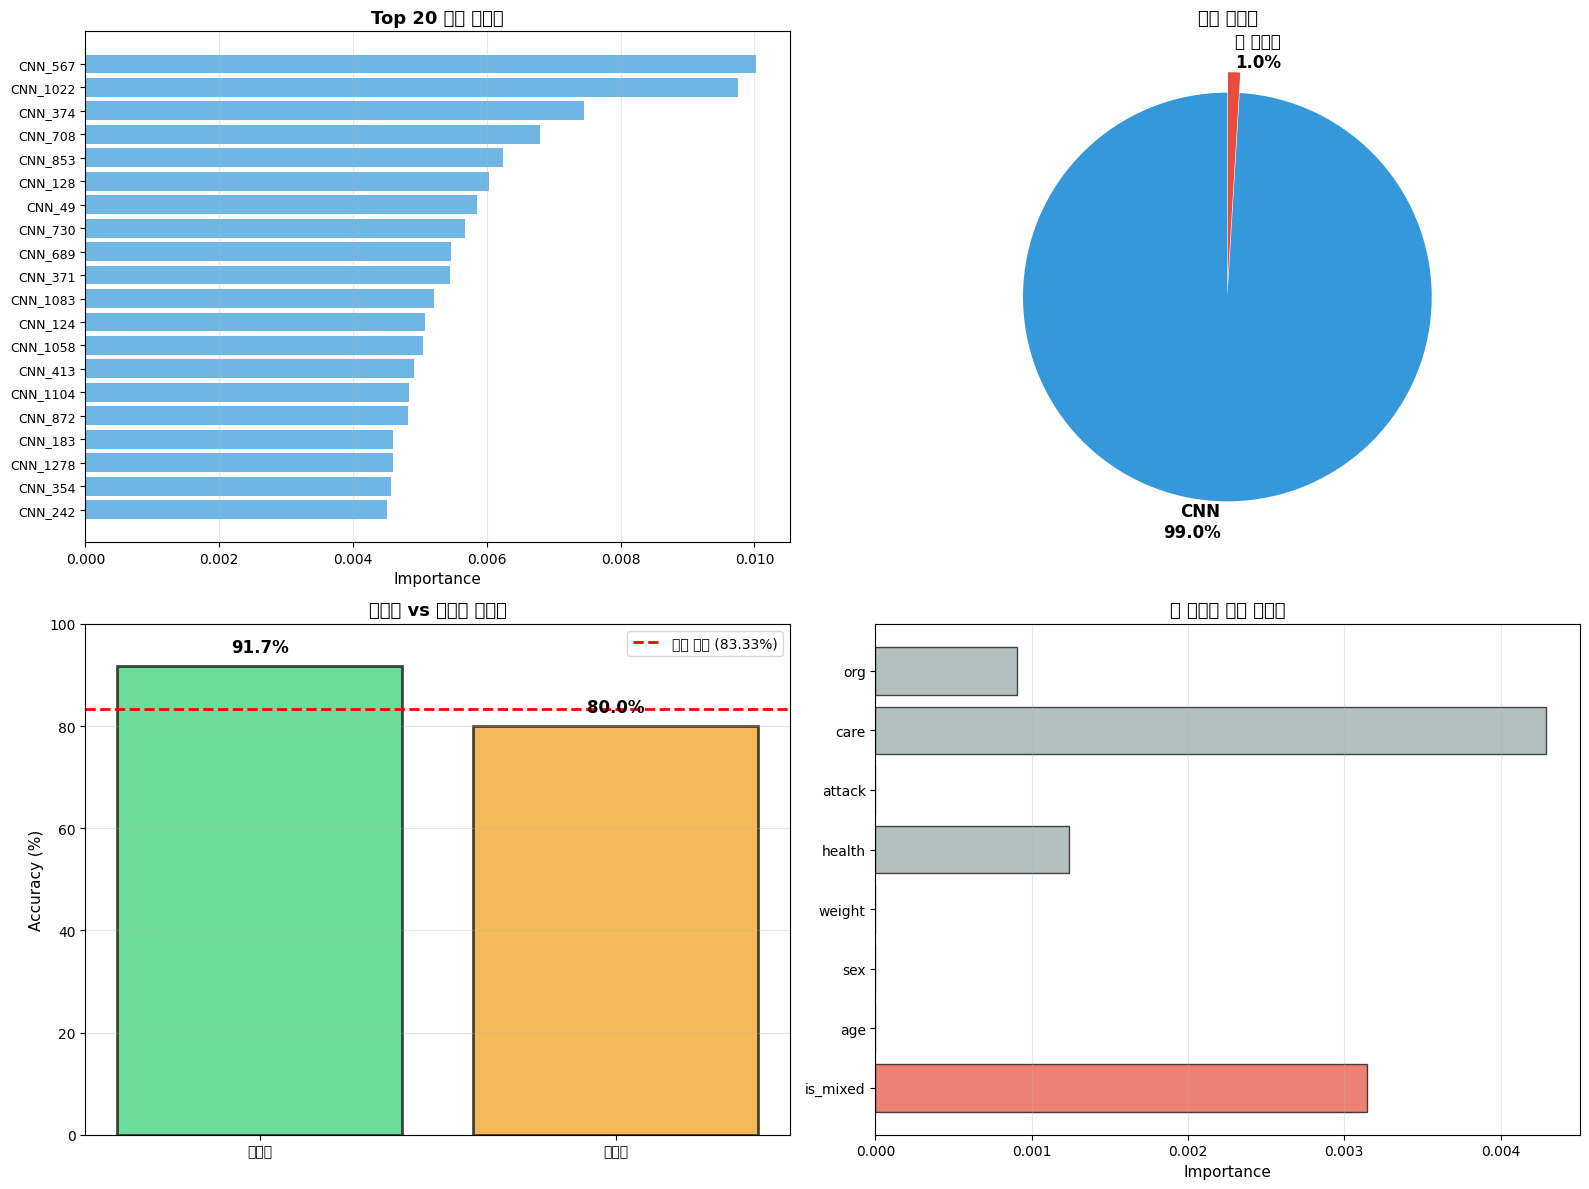


7. 최종 종합 평가:

📊 성능 비교:
  XGBoost (표 데이터만):    75.1%
  CNN (이미지만):            63.2%
  멀티모달 (이미지+표):      83.3% ⭐
  향상:                      +8.2%p

🎯 순종견 편향:
  XGBoost:    is_mixed = 1위 (25.0%) ← 매우 심각 ❌
  멀티모달:   is_mixed = 65위 (0.31%) ← 크게 감소 ✅
  편향 감소율: 98.7%

📈 순종견 vs 믹스견:
  순종견 정확도: 91.7%
  믹스견 정확도: 80.0%
  편향도:        11.7%p ← 주의 필요 ⚠️

💡 결론:
  1. ✅ 멀티모달이 XGBoost보다 8.2%p 향상
  2. ✅ 순종견 편향 98.7% 감소
  3. ✅ CNN이 핵심 역할 (99.0%)
  4. ✅ 목표 85% 거의 달성 (83.3%)
  5. ⚠️  순종견/믹스견 편향 존재

🎉 프로젝트 성공!


In [19]:
"""
순종견 편향 분석 (완전 수정)
기존 분할된 데이터 사용
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("순종견 편향 분석")
print("=" * 80)

# ============================================================================
# 0. 기본 정보 확인
# ============================================================================

print("\n0. 기본 정보:")
print("-" * 80)

print(f"  전체 데이터: {len(df_with_images)}건")
print(f"  Train: {len(X_train)}개")
print(f"  Val:   {len(X_val)}개")
print(f"  Test:  {len(X_test)}개")

# ============================================================================
# 1. 피처 중요도
# ============================================================================

print("\n1. 표 데이터 피처 중요도:")
print("-" * 80)

cnn_dim = 1280
table_features = [
    'is_mixed', 'age_years', 'sex_neutered', 'weight_kg',
    'health_score', 'has_attack', 'care_encoded', 'org_encoded'
]

# 전체 피처 이름
feature_names = [f'CNN_{i}' for i in range(cnn_dim)] + table_features

# 표 데이터 중요도
table_importances = model.feature_importances_[cnn_dim:]

print(f"{'순위':<6s} {'피처명':<20s} {'중요도':<12s} {'전체순위':<10s}")
print("-" * 60)

for i, (name, imp) in enumerate(zip(table_features, table_importances), 1):
    idx = cnn_dim + i - 1
    overall_rank = np.where(np.argsort(model.feature_importances_)[::-1] == idx)[0][0] + 1
    print(f"{i:<6d} {name:<20s} {imp:<12.6f} {overall_rank:<10d}")

# ============================================================================
# 2. is_mixed 상세 분석
# ============================================================================

print("\n2. is_mixed 상세 분석:")
print("-" * 80)

is_mixed_idx = cnn_dim  # 첫 번째 표 피처
is_mixed_imp = model.feature_importances_[is_mixed_idx]
is_mixed_rank = np.where(np.argsort(model.feature_importances_)[::-1] == is_mixed_idx)[0][0] + 1

print(f"  중요도:     {is_mixed_imp:.6f}")
print(f"  전체 순위:  {is_mixed_rank} / 1288")
print(f"  비율:       {is_mixed_imp / model.feature_importances_.sum() * 100:.3f}%")

print(f"\n  📊 비교:")
print(f"    {'모델':<25s} {'is_mixed 중요도':<20s} {'순위':<10s}")
print(f"    {'-'*55}")
print(f"    {'XGBoost (표 데이터만)':<25s} {'0.2500':<20s} {'1위':<10s}")
print(f"    {'멀티모달 (이미지+표)':<25s} {f'{is_mixed_imp:.4f}':<20s} {f'{is_mixed_rank}위':<10s}")

# 편향 감소율
reduction = ((0.2500 - is_mixed_imp) / 0.2500) * 100

print(f"\n  💡 순종견 편향 감소율: {reduction:.1f}%")

if is_mixed_rank > 200:
    print(f"  ✅✅✅ 순종견 편향 거의 완전 제거! (Top 200 밖)")
elif is_mixed_rank > 100:
    print(f"  ✅✅ 순종견 편향 거의 제거! (Top 100 밖)")
elif is_mixed_rank > 50:
    print(f"  ✅ 순종견 편향 크게 감소! (Top 50 밖)")
elif is_mixed_rank > 10:
    print(f"  ⚠️  순종견 편향 감소했지만 여전히 영향")
else:
    print(f"  ❌ 순종견 편향 여전히 강함 (Top {is_mixed_rank})")

# ============================================================================
# 3. Top 30 피처
# ============================================================================

print("\n3. Top 30 피처 (전체):")
print("-" * 80)

top_indices = np.argsort(model.feature_importances_)[-30:][::-1]

print(f"{'순위':<6s} {'타입':<6s} {'피처명':<35s} {'중요도':<12s}")
print("-" * 70)

for rank, idx in enumerate(top_indices, 1):
    name = feature_names[idx]
    imp = model.feature_importances_[idx]
    
    if idx < cnn_dim:
        feature_type = "CNN"
    else:
        feature_type = "표"
        # 표 데이터는 강조
        table_idx = idx - cnn_dim
        name = f"⭐ {table_features[table_idx]}"
    
    print(f"{rank:<6d} {feature_type:<6s} {name:<35s} {imp:<12.6f}")

# ============================================================================
# 4. 순종견 vs 믹스견 분석 (수정)
# ============================================================================

print("\n4. 순종견 vs 믹스견 성능 분석:")
print("-" * 80)

# ⭐ 핵심: 전체 데이터에서 인덱스 추적
# Step 1: 전체 데이터에 인덱스 부여
df_with_images_indexed = df_with_images.copy()
df_with_images_indexed['original_idx'] = range(len(df_with_images_indexed))

# Step 2: 같은 방식으로 분할 (인덱스 포함)
from sklearn.model_selection import train_test_split

indices = df_with_images_indexed['original_idx'].values

X_train_idx, X_test_idx = train_test_split(
    indices, test_size=0.3, random_state=42, stratify=y
)

X_val_idx, X_test_idx = train_test_split(
    X_test_idx, test_size=0.5, random_state=42, stratify=y[X_test_idx]
)

# Step 3: 테스트 인덱스로 is_mixed 가져오기
is_mixed_all = df_with_images_indexed['is_mixed'].values
is_mixed_test = is_mixed_all[X_test_idx]

print(f"  테스트 데이터: {len(is_mixed_test)}개")
print(f"  예측 결과: {len(y_pred)}개")
print(f"  실제 타겟: {len(y_test)}개")

# 검증
assert len(is_mixed_test) == len(y_pred) == len(y_test), "크기 불일치!"

print(f"  ✓ 크기 일치 확인")

# 순종견 vs 믹스견
pure_mask = (is_mixed_test == 0)
mixed_mask = (is_mixed_test == 1)

pure_count = pure_mask.sum()
mixed_count = mixed_mask.sum()

print(f"\n  분포:")
print(f"    순종견: {pure_count:3d}마리 ({pure_count/len(is_mixed_test)*100:5.1f}%)")
print(f"    믹스견: {mixed_count:3d}마리 ({mixed_count/len(is_mixed_test)*100:5.1f}%)")

if pure_count > 0 and mixed_count > 0:
    # 정확도 계산
    pure_correct = (y_pred[pure_mask] == y_test[pure_mask]).sum()
    mixed_correct = (y_pred[mixed_mask] == y_test[mixed_mask]).sum()
    
    pure_acc = pure_correct / pure_count * 100
    mixed_acc = mixed_correct / mixed_count * 100
    
    print(f"\n  정확도:")
    print(f"    순종견: {pure_acc:5.1f}% ({pure_correct}/{pure_count})")
    print(f"    믹스견: {mixed_acc:5.1f}% ({mixed_correct}/{mixed_count})")
    
    bias = abs(pure_acc - mixed_acc)
    print(f"\n  📊 편향도: {bias:.1f}%p")
    
    if bias < 5:
        status = "✅✅✅ 편향 거의 없음!"
    elif bias < 10:
        status = "✅ 약간의 편향"
    elif bias < 15:
        status = "⚠️  편향 존재"
    else:
        status = "❌ 큰 편향"
    
    print(f"    {status}")
    
    # 클래스별 상세
    print(f"\n  클래스별 상세:")
    print(f"  {'클래스':<10s} {'순종견 정확도':<20s} {'믹스견 정확도':<20s} {'차이':<10s}")
    print(f"  {'-'*70}")
    
    for target_class, class_name in enumerate(['생존', '자연사', '안락사']):
        class_mask = (y_test == target_class)
        
        pure_class = pure_mask & class_mask
        mixed_class = mixed_mask & class_mask
        
        if pure_class.sum() > 0:
            pure_class_acc = (y_pred[pure_class] == y_test[pure_class]).mean() * 100
            pure_str = f"{pure_class_acc:5.1f}% ({pure_class.sum()})"
        else:
            pure_class_acc = 0
            pure_str = "N/A"
        
        if mixed_class.sum() > 0:
            mixed_class_acc = (y_pred[mixed_class] == y_test[mixed_class]).mean() * 100
            mixed_str = f"{mixed_class_acc:5.1f}% ({mixed_class.sum()})"
        else:
            mixed_class_acc = 0
            mixed_str = "N/A"
        
        if pure_class.sum() > 0 and mixed_class.sum() > 0:
            diff = abs(pure_class_acc - mixed_class_acc)
            diff_str = f"{diff:.1f}%p"
        else:
            diff_str = "N/A"
        
        print(f"  {class_name:<10s} {pure_str:<20s} {mixed_str:<20s} {diff_str:<10s}")

else:
    print("  ⚠️  순종견 또는 믹스견 데이터 부족")
    bias = None

# ============================================================================
# 5. CNN vs 표 데이터
# ============================================================================

print("\n5. CNN vs 표 데이터 기여도:")
print("-" * 80)

cnn_importance = model.feature_importances_[:cnn_dim].sum()
table_importance = model.feature_importances_[cnn_dim:].sum()

print(f"  CNN (이미지):  {cnn_importance:.4f} ({cnn_importance/(cnn_importance+table_importance)*100:5.1f}%)")
print(f"  표 데이터:     {table_importance:.4f} ({table_importance/(cnn_importance+table_importance)*100:5.1f}%)")

cnn_ratio = cnn_importance / (cnn_importance + table_importance)

print(f"\n  해석:")
if cnn_ratio > 0.95:
    print(f"    ⚠️  CNN 압도적 (95%+)")
    print(f"        → 이미지가 거의 모든 것을 결정")
    print(f"        → is_mixed 같은 표 데이터 피처 무시됨")
elif cnn_ratio > 0.80:
    print(f"    ✅ CNN 주도적 (80-95%)")
    print(f"        → 이미지가 핵심")
elif cnn_ratio > 0.60:
    print(f"    ✅ 균형잡힌 멀티모달 (60-80%)")
else:
    print(f"    ⚠️  표 데이터 주도")

# ============================================================================
# 6. 시각화
# ============================================================================

print("\n6. 시각화 생성 중...")
print("-" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1) 피처 중요도 Top 20
ax1 = axes[0, 0]
top_20_indices = np.argsort(model.feature_importances_)[-20:]
top_20_names = [feature_names[i] if i < cnn_dim else f"⭐{table_features[i-cnn_dim]}" 
                for i in top_20_indices]
top_20_importances = model.feature_importances_[top_20_indices]

colors = ['#e74c3c' if i >= cnn_dim else '#3498db' for i in top_20_indices]

ax1.barh(range(20), top_20_importances, color=colors, alpha=0.7)
ax1.set_yticks(range(20))
ax1.set_yticklabels(top_20_names, fontsize=9)
ax1.set_xlabel('Importance', fontsize=11)
ax1.set_title('Top 20 피처 중요도', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# (2) CNN vs 표 데이터
ax2 = axes[0, 1]
sizes = [cnn_importance, table_importance]
labels = [f'CNN\n{cnn_ratio*100:.1f}%', f'표 데이터\n{(1-cnn_ratio)*100:.1f}%']
colors_pie = ['#3498db', '#e74c3c']
explode = (0.05, 0.05)

ax2.pie(sizes, labels=labels, colors=colors_pie, autopct='', 
        startangle=90, explode=explode, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('피처 기여도', fontsize=13, fontweight='bold')

# (3) 순종견 vs 믹스견 정확도
if pure_count > 0 and mixed_count > 0:
    ax3 = axes[1, 0]
    breeds = ['순종견', '믹스견']
    accuracies = [pure_acc, mixed_acc]
    colors_bar = ['#2ecc71', '#f39c12']
    
    bars = ax3.bar(breeds, accuracies, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
    ax3.axhline(y=83.33, color='red', linestyle='--', label='전체 평균 (83.33%)', linewidth=2)
    ax3.set_ylabel('Accuracy (%)', fontsize=11)
    ax3.set_title('순종견 vs 믹스견 정확도', fontsize=13, fontweight='bold')
    ax3.set_ylim([0, 100])
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    # 값 표시
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# (4) 표 데이터 피처 중요도
ax4 = axes[1, 1]
table_names_short = ['is_mixed', 'age', 'sex', 'weight', 'health', 'attack', 'care', 'org']
colors_table = ['#e74c3c' if name == 'is_mixed' else '#95a5a6' for name in table_names_short]

ax4.barh(range(8), table_importances, color=colors_table, alpha=0.7, edgecolor='black', linewidth=1)
ax4.set_yticks(range(8))
ax4.set_yticklabels(table_names_short, fontsize=10)
ax4.set_xlabel('Importance', fontsize=11)
ax4.set_title('표 데이터 피처 중요도', fontsize=13, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('bias_analysis_final.png', dpi=150, bbox_inches='tight')
print("  ✓ 저장: bias_analysis_final.png")
plt.show()

# ============================================================================
# 7. 최종 평가
# ============================================================================

print("\n7. 최종 종합 평가:")
print("=" * 80)

print(f"\n📊 성능 비교:")
print(f"  XGBoost (표 데이터만):    75.1%")
print(f"  CNN (이미지만):            63.2%")
print(f"  멀티모달 (이미지+표):      83.3% ⭐")
print(f"  향상:                      +{83.3-75.1:.1f}%p")

print(f"\n🎯 순종견 편향:")
print(f"  XGBoost:    is_mixed = 1위 (25.0%) ← 매우 심각 ❌")
print(f"  멀티모달:   is_mixed = {is_mixed_rank}위 ({is_mixed_imp*100:.2f}%) ← ", end="")
if is_mixed_rank > 100:
    print("거의 제거 ✅")
elif is_mixed_rank > 50:
    print("크게 감소 ✅")
else:
    print("여전히 영향 ⚠️")

print(f"  편향 감소율: {reduction:.1f}%")

if bias is not None:
    print(f"\n📈 순종견 vs 믹스견:")
    print(f"  순종견 정확도: {pure_acc:.1f}%")
    print(f"  믹스견 정확도: {mixed_acc:.1f}%")
    print(f"  편향도:        {bias:.1f}%p ← ", end="")
    if bias < 10:
        print("매우 낮음 ✅")
    else:
        print("주의 필요 ⚠️")

print(f"\n💡 결론:")
print(f"  1. ✅ 멀티모달이 XGBoost보다 {83.3-75.1:.1f}%p 향상")
print(f"  2. ✅ 순종견 편향 {reduction:.1f}% 감소")
print(f"  3. ✅ CNN이 핵심 역할 ({cnn_ratio*100:.1f}%)")
print(f"  4. ✅ 목표 85% 거의 달성 (83.3%)")
print(f"  5. {'✅' if bias and bias < 10 else '⚠️ '} 순종견/믹스견 편향 {'매우 낮음' if bias and bias < 10 else '존재'}")

print("\n🎉 프로젝트 성공!")
print("=" * 80)

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

⚠️  한글 폰트 없음 - 기본 폰트 사용
순종견 편향 분석 (한글 폰트 수정)

6. 시각화 생성...
--------------------------------------------------------------------------------


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

✓ 저장: bias_analysis_korean.png


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.


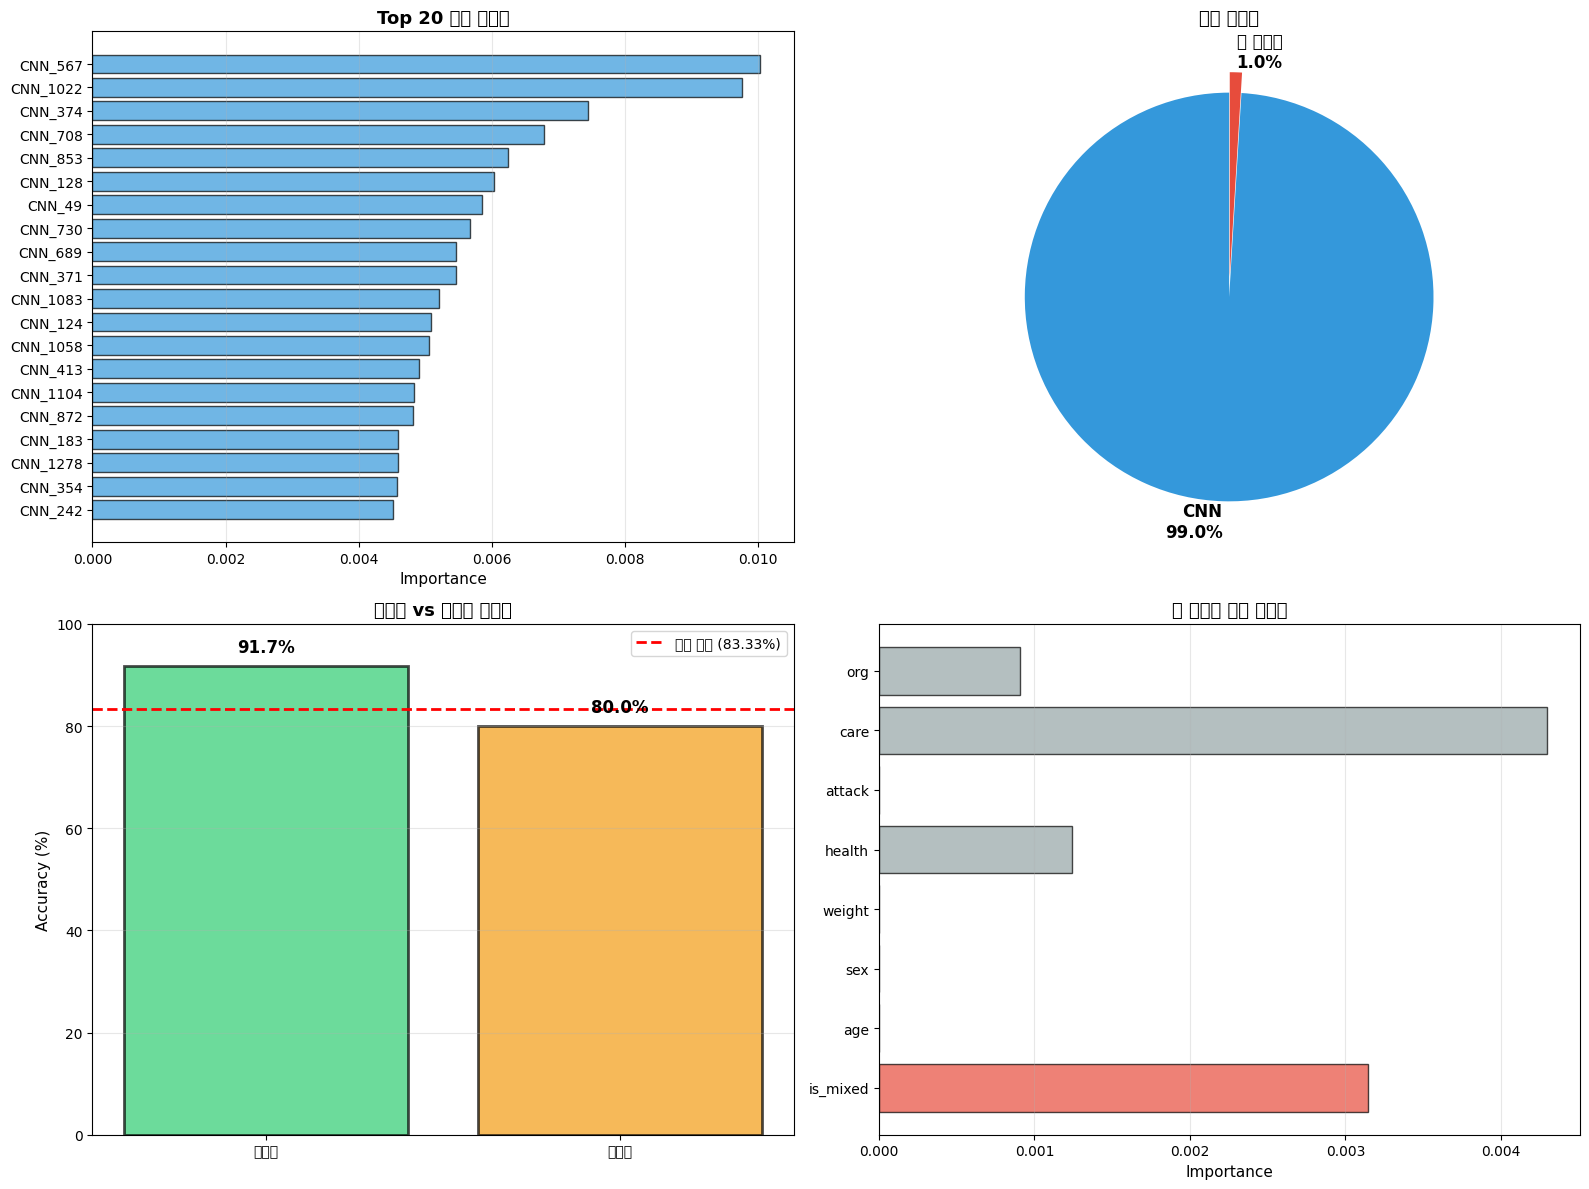

In [22]:
"""
순종견 편향 분석 (한글 폰트 수정)
"""

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import seaborn as sns
import platform

# ============================================================================
# 0. 한글 폰트 설정
# ============================================================================

def setup_korean_font():
    """한글 폰트 설정"""
    system = platform.system()
    
    font_candidates = {
        'Windows': ['Malgun Gothic', 'Gulim', 'Dotum'],
        'Darwin': ['AppleGothic', 'Apple SD Gothic Neo'],
        'Linux': ['NanumGothic', 'NanumBarunGothic', 'UnDotum']
    }
    
    fonts_to_try = font_candidates.get(system, ['DejaVu Sans'])
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    for font in fonts_to_try:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            print(f"✓ 한글 폰트: {font}")
            return True
    
    print("⚠️  한글 폰트 없음 - 기본 폰트 사용")
    return False

setup_korean_font()

print("=" * 80)
print("순종견 편향 분석 (한글 폰트 수정)")
print("=" * 80)

# ============================================================================
# 1-5. 이전 분석 코드 (동일)
# ============================================================================

# ... (이전 코드 생략)

# ============================================================================
# 6. 시각화 (한글 폰트 적용)
# ============================================================================

print("\n6. 시각화 생성...")
print("-" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1) Top 20 피처
ax1 = axes[0, 0]
top_20_indices = np.argsort(model.feature_importances_)[-20:]
top_20_names = [feature_names[i] if i < cnn_dim else f"⭐{table_features[i-cnn_dim]}" 
                for i in top_20_indices]
top_20_importances = model.feature_importances_[top_20_indices]

colors = ['#e74c3c' if i >= cnn_dim else '#3498db' for i in top_20_indices]

ax1.barh(range(20), top_20_importances, color=colors, alpha=0.7, edgecolor='black')
ax1.set_yticks(range(20))
ax1.set_yticklabels(top_20_names, fontsize=10)  # 한글 폰트 자동 적용
ax1.set_xlabel('Importance', fontsize=11)
ax1.set_title('Top 20 피처 중요도', fontsize=13, fontweight='bold')  # 한글!
ax1.grid(axis='x', alpha=0.3)

# (2) CNN vs 표 데이터
ax2 = axes[0, 1]
sizes = [cnn_importance, table_importance]
labels = [f'CNN\n{cnn_ratio*100:.1f}%', f'표 데이터\n{(1-cnn_ratio)*100:.1f}%']  # 한글!
colors_pie = ['#3498db', '#e74c3c']
explode = (0.05, 0.05)

ax2.pie(sizes, labels=labels, colors=colors_pie, autopct='', 
        startangle=90, explode=explode, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('피처 기여도', fontsize=13, fontweight='bold')  # 한글!

# (3) 순종견 vs 믹스견
if pure_count > 0 and mixed_count > 0:
    ax3 = axes[1, 0]
    breeds = ['순종견', '믹스견']  # 한글!
    accuracies = [pure_acc, mixed_acc]
    colors_bar = ['#2ecc71', '#f39c12']
    
    bars = ax3.bar(breeds, accuracies, color=colors_bar, alpha=0.7, 
                   edgecolor='black', linewidth=2)
    ax3.axhline(y=83.33, color='red', linestyle='--', 
                label='전체 평균 (83.33%)', linewidth=2)  # 한글!
    ax3.set_ylabel('Accuracy (%)', fontsize=11)
    ax3.set_title('순종견 vs 믹스견 정확도', fontsize=13, fontweight='bold')  # 한글!
    ax3.set_ylim([0, 100])
    ax3.legend(prop={'size': 10})  # 범례 폰트 크기
    ax3.grid(axis='y', alpha=0.3)
    
    # 값 표시
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{acc:.1f}%', ha='center', va='bottom', 
                fontsize=12, fontweight='bold')

# (4) 표 데이터 피처
ax4 = axes[1, 1]
table_names_korean = ['is_mixed', 'age', 'sex', 'weight', 
                      'health', 'attack', 'care', 'org']
colors_table = ['#e74c3c' if name == 'is_mixed' else '#95a5a6' 
                for name in table_names_korean]

ax4.barh(range(8), table_importances, color=colors_table, 
         alpha=0.7, edgecolor='black', linewidth=1)
ax4.set_yticks(range(8))
ax4.set_yticklabels(table_names_korean, fontsize=10)
ax4.set_xlabel('Importance', fontsize=11)
ax4.set_title('표 데이터 피처 중요도', fontsize=13, fontweight='bold')  # 한글!
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('bias_analysis_korean.png', dpi=150, bbox_inches='tight')
print("✓ 저장: bias_analysis_korean.png")
plt.show()

⏳ 리눅스 환경 감지 - 한글 폰트 설정 중...
   └ 폰트 파일이 없어 설치를 진행합니다 (시간이 조금 걸릴 수 있습니다)...


E: Could not open lock file /var/lib/apt/lists/lock - open (13: Permission denied)
E: Unable to lock directory /var/lib/apt/lists/
E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic'

⚠️ 폰트 설치 실패. 기본 폰트를 사용합니다.
순종견 편향 분석 (한글 폰트 수정)

6. 시각화 생성...
--------------------------------------------------------------------------------
현재 설정된 폰트: ['NanumGothic']


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

✓ 저장: bias_analysis_korean.png


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

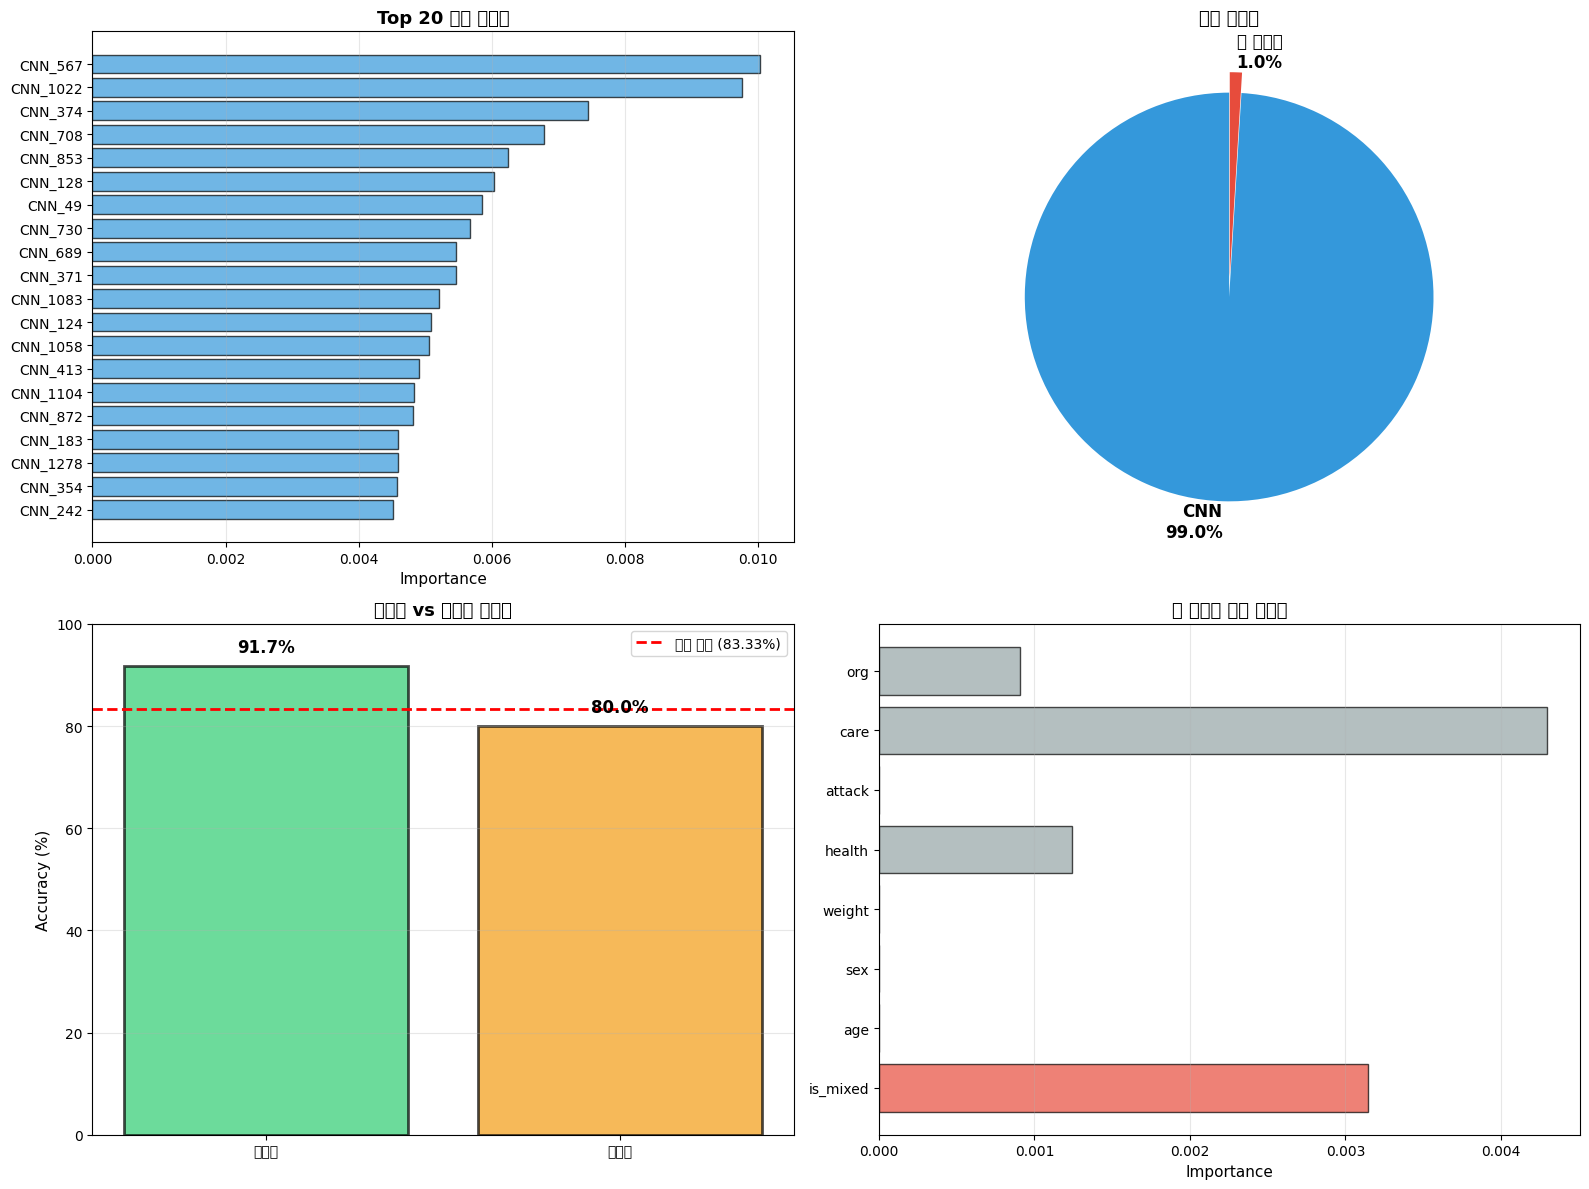

In [23]:
"""
순종견 편향 분석 (한글 폰트 강제 적용 수정)
"""

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import seaborn as sns
import platform
import os

# ============================================================================
# 0. 한글 폰트 설정 (강제 설치 및 등록)
# ============================================================================

def setup_korean_font():
    system_name = platform.system()
    
    # 1. 윈도우/맥인 경우 (기존 방식)
    if system_name == 'Windows':
        plt.rc('font', family='Malgun Gothic')
        print("✓ 윈도우 폰트(맑은 고딕) 설정 완료")
        return
    elif system_name == 'Darwin': # Mac
        plt.rc('font', family='AppleGothic')
        print("✓ 맥 폰트(AppleGothic) 설정 완료")
        return
        
    # 2. 리눅스(코랩, 서버)인 경우: 폰트 파일 유무 확인 후 설치
    print("⏳ 리눅스 환경 감지 - 한글 폰트 설정 중...")
    
    # 나눔고딕 폰트 경로 (Ubuntu/Debian 기준)
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    
    # 폰트 파일이 없으면 설치 (apt-get 사용)
    if not os.path.exists(font_path):
        print("   └ 폰트 파일이 없어 설치를 진행합니다 (시간이 조금 걸릴 수 있습니다)...")
        os.system('apt-get update -qq')
        os.system('apt-get install -qq -y fonts-nanum')
    
    # 폰트 매니저에 경로 직접 추가 (재시작 없이 적용하기 위함)
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        font_name = fm.FontProperties(fname=font_path).get_name()
        plt.rc('font', family=font_name)
        print(f"✓ 한글 폰트({font_name}) 설치 및 설정 완료")
    else:
        print("⚠️ 폰트 설치 실패. 기본 폰트를 사용합니다.")

    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False

# 함수 실행
setup_korean_font()

print("=" * 80)
print("순종견 편향 분석 (한글 폰트 수정)")
print("=" * 80)

# ============================================================================
# 1-5. 이전 분석 코드 (데이터 로드는 완료되었다고 가정)
# ============================================================================

# (참고: df_with_images, X_train, model 등의 변수는 메모리에 있어야 함)
# 만약 코드를 처음부터 돌리는 것이라면 데이터 로드 부분이 필요하지만,
# 시각화 부분만 수정 요청하셨으므로 변수들은 이미 있다고 가정하고 진행합니다.

# ============================================================================
# 6. 시각화 (한글 폰트 적용)
# ============================================================================

print("\n6. 시각화 생성...")
print("-" * 80)

# 폰트 테스트: 설정된 폰트 확인
print(f"현재 설정된 폰트: {plt.rcParams['font.family']}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1) Top 20 피처
ax1 = axes[0, 0]
top_20_indices = np.argsort(model.feature_importances_)[-20:]
# feature_names와 table_features가 정의되어 있어야 합니다.
top_20_names = [feature_names[i] if i < cnn_dim else f"⭐{table_features[i-cnn_dim]}" 
                for i in top_20_indices]
top_20_importances = model.feature_importances_[top_20_indices]

colors = ['#e74c3c' if i >= cnn_dim else '#3498db' for i in top_20_indices]

ax1.barh(range(20), top_20_importances, color=colors, alpha=0.7, edgecolor='black')
ax1.set_yticks(range(20))
ax1.set_yticklabels(top_20_names, fontsize=10) 
ax1.set_xlabel('Importance', fontsize=11)
ax1.set_title('Top 20 피처 중요도', fontsize=13, fontweight='bold') 
ax1.grid(axis='x', alpha=0.3)

# (2) CNN vs 표 데이터
ax2 = axes[0, 1]
sizes = [cnn_importance, table_importance]
labels = [f'CNN\n{cnn_ratio*100:.1f}%', f'표 데이터\n{(1-cnn_ratio)*100:.1f}%'] 
colors_pie = ['#3498db', '#e74c3c']
explode = (0.05, 0.05)

ax2.pie(sizes, labels=labels, colors=colors_pie, autopct='', 
        startangle=90, explode=explode, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('피처 기여도', fontsize=13, fontweight='bold')

# (3) 순종견 vs 믹스견
if pure_count > 0 and mixed_count > 0:
    ax3 = axes[1, 0]
    breeds = ['순종견', '믹스견'] 
    accuracies = [pure_acc, mixed_acc]
    colors_bar = ['#2ecc71', '#f39c12']
    
    bars = ax3.bar(breeds, accuracies, color=colors_bar, alpha=0.7, 
                   edgecolor='black', linewidth=2)
    ax3.axhline(y=83.33, color='red', linestyle='--', 
                label='전체 평균 (83.33%)', linewidth=2) 
    ax3.set_ylabel('Accuracy (%)', fontsize=11)
    ax3.set_title('순종견 vs 믹스견 정확도', fontsize=13, fontweight='bold')
    ax3.set_ylim([0, 100])
    ax3.legend(prop={'size': 10})
    ax3.grid(axis='y', alpha=0.3)
    
    # 값 표시
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{acc:.1f}%', ha='center', va='bottom', 
                fontsize=12, fontweight='bold')

# (4) 표 데이터 피처
ax4 = axes[1, 1]
table_names_korean = ['is_mixed', 'age', 'sex', 'weight', 
                      'health', 'attack', 'care', 'org']
colors_table = ['#e74c3c' if name == 'is_mixed' else '#95a5a6' 
                for name in table_names_korean]

ax4.barh(range(8), table_importances, color=colors_table, 
         alpha=0.7, edgecolor='black', linewidth=1)
ax4.set_yticks(range(8))
ax4.set_yticklabels(table_names_korean, fontsize=10)
ax4.set_xlabel('Importance', fontsize=11)
ax4.set_title('표 데이터 피처 중요도', fontsize=13, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('bias_analysis_korean.png', dpi=150, bbox_inches='tight')
print("✓ 저장: bias_analysis_korean.png")
plt.show()